In [ ]:
%matplotlib inline

In [ ]:
# Imports
import os
import pathlib
SALVUS_FLOW_SITE_NAME = os.environ.get("salome_remote") # Site name given in the installation of Salvus flow
PROJECT_DIR_VECTOR = "simulation_wavefield_output_larger"  
PROJECT_DIR_TENSOR = "simulation_wavefield_output_moment_tensor_bigger"  
PROJECT_DIR_MOVING_SUBSUB = "simulation_wavefield_moving_source_momentt_subrayleigh" 
PROJECT_DIR_MOVING_SUB = "simulation_wavefield_moving_source_momentt_slight_subrayleigh" 
PROJECT_DIR_MOVING_MOMENTT = "simulation_wavefield_moving_source_momentt"
PROJECT_DIR_MOM_X = "simulation_wavefield_moving_source_moment_slight_subrayleigh_x"
PROJECT_DIR_VEC_X = "simulation_wavefield_moving_source_vector_slight_subrayleigh_x_pos"
PROJECT_DIR_VEC_Y_NEG = "simulation_wavefield_moving_source_vector_slight_subrayleigh_vertical_neg"
PROJECT_DIR_VEC_Y_POS = "simulation_wavefield_moving_source_vector_slight_subrayleigh_vertical_pos"
PROJECT_DIR_VEC_BOTH = "simulation_wavefield_moving_source_vector_slight_subrayleigh_both"
PROJECT_DIR_FAULT = "simulation_fault_zone"
PROJECT_DIR_CZM = "simulation_fault_zone_czm_adjusted_time_sub_m1"
PROJECT_DIR_MODE_I = "simulation_fault_zone_czm_mode1"
PROJECT_DIR_MODE_II = "simulation_fault_zone_czm_mode2"
PROJECT_DIR_CZM_SUPERSHEAR = "simulation_fault_zone_czm_adjusted_time_super_m1" 
PROJECT_DIR_CZM_SUPERSHEAR_LINEAR = "simulation_fault_zone_czm_adjusted_time_super_linear_m1"
PROJECT_DIR_CZM_SUB_LINEAR = "simulation_fault_zone_czm_adjusted_time_sub_linear_m1"
PROJECT_DIR_CZM_SUB_LINEAR_F20 = "simulation_fault_zone_czm_adjusted_time_sub_linear_m1_f20"
PROJECT_DIR_CZM_SUPER_LINEAR_F20_SUPER = "simulation_fault_zone_czm_adjusted_time_super_linear_m1_f20"


# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR_VECTOR not in contents:
        f.write(f"\n{PROJECT_DIR_VECTOR }/\n")
    if PROJECT_DIR_TENSOR not in contents:
        f.write(f"\n{PROJECT_DIR_TENSOR }/\n")
    if PROJECT_DIR_MOVING_SUBSUB not in contents:
        f.write(f"\n{PROJECT_DIR_MOVING_SUBSUB }/\n")
    if PROJECT_DIR_MOVING_SUB not in contents:
        f.write(f"\n{PROJECT_DIR_MOVING_SUB }/\n")
    if PROJECT_DIR_MOVING_MOMENTT not in contents:
        f.write(f"\n{PROJECT_DIR_MOVING_MOMENTT }/\n")
    if PROJECT_DIR_MOM_X not in contents:
        f.write(f"\n{PROJECT_DIR_MOM_X }/\n")
    if PROJECT_DIR_VEC_X not in contents:
        f.write(f"\n{PROJECT_DIR_VEC_X }/\n")
    if PROJECT_DIR_VEC_Y_NEG not in contents:
        f.write(f"\n{PROJECT_DIR_VEC_Y_NEG }/\n")
    if PROJECT_DIR_VEC_Y_POS not in contents:
        f.write(f"\n{PROJECT_DIR_VEC_Y_POS }/\n")
    if PROJECT_DIR_VEC_BOTH not in contents:
        f.write(f"\n{PROJECT_DIR_VEC_BOTH }/\n")    
    if PROJECT_DIR_FAULT not in contents:
        f.write(f"\n{PROJECT_DIR_FAULT }/\n")
    if PROJECT_DIR_CZM not in contents:
        f.write(f"\n{PROJECT_DIR_CZM }/\n")
    if PROJECT_DIR_MODE_I not in contents:
        f.write(f"\n{PROJECT_DIR_MODE_I }/\n")
    if PROJECT_DIR_MODE_II not in contents:
        f.write(f"\n{PROJECT_DIR_MODE_II }/\n")

import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

In [ ]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=300, y0=0, y1=3)
domain_2d_adjusted = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)  # for CZM supershear to capture the wavefield better
p_v = sn.Project.from_domain(path=PROJECT_DIR_VECTOR, domain=domain_2d, load_if_exists=True)
p_t = sn.Project.from_domain(path=PROJECT_DIR_TENSOR, domain=domain_2d, load_if_exists=True)
p_moving_subsub = sn.Project.from_domain(path=PROJECT_DIR_MOVING_SUBSUB, domain=domain_2d, load_if_exists=True)
p_moving_sub = sn.Project.from_domain(path=PROJECT_DIR_MOVING_SUB, domain=domain_2d, load_if_exists=True)
p_moving_momentt = sn.Project.from_domain(path=PROJECT_DIR_MOVING_MOMENTT, domain=domain_2d, load_if_exists=True)
p_mom_x = sn.Project.from_domain(path=PROJECT_DIR_MOM_X, domain=domain_2d, load_if_exists=True)
p_vec_x = sn.Project.from_domain(path=PROJECT_DIR_VEC_X, domain=domain_2d, load_if_exists=True)
p_vec_y_neg = sn.Project.from_domain(path=PROJECT_DIR_VEC_Y_NEG, domain=domain_2d, load_if_exists=True)
p_vec_y_pos = sn.Project.from_domain(path=PROJECT_DIR_VEC_Y_POS, domain=domain_2d, load_if_exists=True)
p_vec_both = sn.Project.from_domain(path=PROJECT_DIR_VEC_BOTH, domain=domain_2d, load_if_exists=True)
p_fault = sn.Project.from_domain(path=PROJECT_DIR_FAULT, domain=domain_2d, load_if_exists=True)
p_czm = sn.Project.from_domain(path=PROJECT_DIR_CZM, domain=domain_2d_adjusted, load_if_exists=True)
p_czm_supershear = sn.Project.from_domain(path=PROJECT_DIR_CZM_SUPERSHEAR, domain=domain_2d_adjusted, load_if_exists=True)
p_mode_i = sn.Project.from_domain(path=PROJECT_DIR_MODE_I, domain=domain_2d_adjusted, load_if_exists=True)
p_mode_ii = sn.Project.from_domain(path=PROJECT_DIR_MODE_II, domain=domain_2d_adjusted, load_if_exists=True)
p_czm_supershear_linear = sn.Project.from_domain(path=PROJECT_DIR_CZM_SUPERSHEAR_LINEAR, domain=domain_2d_adjusted, load_if_exists=True)
p_czm_sub_linear = sn.Project.from_domain(path=PROJECT_DIR_CZM_SUB_LINEAR, domain=domain_2d_adjusted, load_if_exists=True)
p_czm_sub_linear_f20 = sn.Project.from_domain(path=PROJECT_DIR_CZM_SUB_LINEAR_F20, domain=domain_2d_adjusted, load_if_exists=True)
p_czm_super_linear_f20_super = sn.Project.from_domain(path=PROJECT_DIR_CZM_SUPER_LINEAR_F20_SUPER, domain=domain_2d_adjusted, load_if_exists=True)


In [ ]:
# Extract velocity wavefield output for CZM sub-Rayleigh and CZM supershear runs.

# Expected output folders from the launch workflow.
czm_output_folder = str(pathlib.Path(PROJECT_DIR_CZM) / "job_snow_crack_czm")
czm_supershear_output_folder = str(pathlib.Path(PROJECT_DIR_CZM_SUPERSHEAR) / "job_snow_crack_czm")

# Expected output files for each dataset.
czm_vol_file = pathlib.Path(czm_output_folder) / "volume_data_czm.h5"
czm_supershear_vol_file = pathlib.Path(czm_supershear_output_folder) / "volume_data_czm.h5"

if not czm_vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {czm_vol_file}. Re-run the CZM launch cell and verify the job completed."
    )

if not czm_supershear_vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {czm_supershear_vol_file}. Re-run the CZM supershear launch cell and verify the job completed."
    )

# Keep '_v' and '_t' variable names for downstream plotting compatibility.
# '_v' now maps to CZM sub-Rayleigh, '_t' maps to CZM supershear.
vel_wo_layered_v = wavefield_output.WavefieldOutput.from_file(
    czm_vol_file,
    "velocity",
    "volume",
)

vel_2d_layered_v = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered_v,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

vel_wo_layered_t = wavefield_output.WavefieldOutput.from_file(
    czm_supershear_vol_file,
    "velocity",
    "volume",
)

vel_2d_layered_t = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered_t,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

print(f"Loaded CZM sub-Rayleigh velocity from {czm_vol_file}")
print(f"Loaded CZM supershear velocity from {czm_supershear_vol_file}")
print("CZM sub-Rayleigh dims:", vel_2d_layered_v.dims)
print("CZM supershear dims:", vel_2d_layered_t.dims)

In [ ]:
# Load displacement fields for CZM sub-Rayleigh and CZM supershear runs.

# Keep '_v' and '_t' variable names for downstream plotting compatibility.
# '_v' now maps to CZM sub-Rayleigh, '_t' maps to CZM supershear.
dis_wo_layered_v = wavefield_output.WavefieldOutput.from_file(
    czm_vol_file,
    "displacement",
    "volume",
)

dis_2d_layered_v = wavefield_output.wavefield_output_to_xarray(
    dis_wo_layered_v,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

dis_wo_layered_t = wavefield_output.WavefieldOutput.from_file(
    czm_supershear_vol_file,
    "displacement",
    "volume",
)

dis_2d_layered_t = wavefield_output.wavefield_output_to_xarray(
    dis_wo_layered_t,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

print(f"Loaded CZM sub-Rayleigh displacement from {czm_vol_file}")
print(f"Loaded CZM supershear displacement from {czm_supershear_vol_file}")
print("CZM sub-Rayleigh dims:", dis_2d_layered_v.dims)
print("CZM supershear dims:", dis_2d_layered_t.dims)


# Also calculate strain (spatial derivative of displacement).
x_dim_v = next((dim for dim in ["x", "X", "p0", "dim_0"] if dim in dis_2d_layered_v.dims or dim in dis_2d_layered_v.coords), None)

if x_dim_v is None:
    raise ValueError(
        f"Could not find an x-like spatial dimension in dims={dis_2d_layered_v.dims}, coords={list(dis_2d_layered_v.coords)}"
    )

dis_2d_layered_dx_v = dis_2d_layered_v.differentiate(x_dim_v)

print(f"Computed spatial derivative d/d{x_dim_v} for dis_2d_layered_v")
print(dis_2d_layered_dx_v)

x_dim_t = next((dim for dim in ["x", "X", "p0", "dim_0"] if dim in dis_2d_layered_t.dims or dim in dis_2d_layered_t.coords), None)

if x_dim_t is None:
    raise ValueError(
        f"Could not find an x-like spatial dimension in dims={dis_2d_layered_t.dims}, coords={list(dis_2d_layered_t.coords)}"
    )

dis_2d_layered_dx_t = dis_2d_layered_t.differentiate(x_dim_t)

print(f"Computed spatial derivative d/d{x_dim_t} for dis_2d_layered_t")
print(dis_2d_layered_dx_t)

In [ ]:
# # Extracting moving-source wavefield output for all available moving-source events
# x_line_m = np.linspace(0.0, 300.0, 1001)
# y_surface_m = 3 * 2 / 3
# y_line_m = np.full_like(x_line_m, y_surface_m)

# # Keep the same moving-source x-grid as in moving_source.ipynb
# x_positions_m = np.arange(0.0, 300.0, 15.0)

# def extract_moving_receiver_section(project, x_positions):
#     """Extract vy along receiver line for all available moving-source events in one project."""
#     sections = []

#     for i, x_src in enumerate(x_positions):
#         sim_name = f"sim_2d_layered_moving_source_{i:03d}"
#         event_name = f"event_wavefield_output_x{i:03d}"

#         try:
#             out_dir = project.simulations.get_simulation_output_directory(sim_name, event_name)
#             vel_wo = wavefield_output.WavefieldOutput.from_file(
#                 pathlib.Path(out_dir, "volume_data_output.h5"),
#                 "velocity",
#                 "volume",
#             )
#         except Exception:
#             # Skip missing / failed events while still collecting all available outputs.
#             continue

#         vel_sg = wavefield_output.wavefield_output_to_xarray(
#             vel_wo,
#             points=np.column_stack((x_line_m, y_line_m)),
#         )
#         sg_vy = vel_sg.isel(c=1)
#         sg_vy = sg_vy.expand_dims(event_index=[float(x_src)])
#         sections.append(sg_vy)

#     if not sections:
#         raise ValueError("No moving-source wavefield outputs found for this project.")

#     return xr.concat(sections, dim="event_index")

# sg_moving_subsub = extract_moving_receiver_section(p_moving_subsub, x_positions_m)
# sg_moving_sub = extract_moving_receiver_section(p_moving_sub, x_positions_m)
# sg_moving_momentt = extract_moving_receiver_section(p_moving_momentt, x_positions_m)

# print("Loaded moving-source receiver sections:")
# print("  subrayleigh:", sg_moving_subsub.sizes)
# print("  slight_subrayleigh:", sg_moving_sub.sizes)
# print("  reference moving moment tensor:", sg_moving_momentt.sizes)

In [ ]:
# # Plot moving-source waterfall sections (mean across all moving events per project)
# def prepare_mean_section(sg_events):
#     sg_mean = sg_events.mean(dim="event_index")
#     t_vals = sg_mean.t.values
#     data = sg_mean.values
#     vmax = np.percentile(np.abs(data), 95)
#     return t_vals, data, vmax

# t_subsub, data_subsub, vmax_subsub = prepare_mean_section(sg_moving_subsub)
# t_sub, data_sub, vmax_sub = prepare_mean_section(sg_moving_sub)
# t_momentt, data_momentt, vmax_momentt = prepare_mean_section(sg_moving_momentt)

# fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)

# im0 = axes[0].pcolormesh(
#     x_line_m, t_subsub, data_subsub,
#     shading="gouraud",
#     cmap="RdBu_r",
#     vmin=-vmax_subsub, vmax=vmax_subsub,
#  )
# axes[0].invert_yaxis()
# axes[0].set_xlabel("Distance (m)")
# axes[0].set_ylabel("Time (s)")
# axes[0].set_xlim(0, 300)
# axes[0].set_title("Moving source - subrayleigh")
# for x_src in sg_moving_subsub.event_index.values:
#     axes[0].axvline(x=float(x_src), color="teal", lw=0.4, linestyle="--", alpha=0.30)
# fig.colorbar(im0, ax=axes[0], label="Vertical particle velocity (m/s)")

# im1 = axes[1].pcolormesh(
#     x_line_m, t_sub, data_sub,
#     shading="gouraud",
#     cmap="RdBu_r",
#     vmin=-vmax_sub, vmax=vmax_sub,
#  )
# axes[1].set_xlabel("Distance (m)")
# axes[1].set_xlim(0, 300)
# axes[1].set_title("Moving source - slight subrayleigh")
# for x_src in sg_moving_sub.event_index.values:
#     axes[1].axvline(x=float(x_src), color="teal", lw=0.4, linestyle="--", alpha=0.30)
# fig.colorbar(im1, ax=axes[1], label="Vertical particle velocity (m/s)")

# im2 = axes[2].pcolormesh(
#     x_line_m, t_momentt, data_momentt,
#     shading="gouraud",
#     cmap="RdBu_r",
#     vmin=-vmax_momentt, vmax=vmax_momentt,
#  )
# axes[2].set_xlabel("Distance (m)")
# axes[2].set_xlim(0, 300)
# axes[2].set_title("Moving source - reference moment tensor (supershear)")
# for x_src in sg_moving_momentt.event_index.values:
#     axes[2].axvline(x=float(x_src), color="teal", lw=0.4, linestyle="--", alpha=0.30)
# fig.colorbar(im2, ax=axes[2], label="Vertical particle velocity (m/s)")

# fig.suptitle(
#     "Moving-source receiver-line waterfall plots (mean over all moving events)",
#     y=1.03,
#     fontsize=12,
#  )
# plt.tight_layout()
# plt.show()

In [ ]:
# Plot CZM sub-Rayleigh and CZM supershear waterfall plots next to each other.
from IPython.display import display

# Define receiver line
y_surface = 1.5 * 3 / 3  # middle of snow layer

def _prepare_receiver_section(vel_2d_layered, y_surface_value):
    # Resolve coordinate / dimension names robustly (same approach as rupture_test).
    coords_set = set(vel_2d_layered.coords)
    dims_set = set(vel_2d_layered.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
    e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}"
        )

    # Vertical component at chosen receiver depth.
    sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface_value}, method="nearest")

    # Keep all events by reducing event dimension if present.
    if e_name is not None and e_name in sg_vy.dims:
        sg_vy_plot = sg_vy.mean(dim=e_name)
    else:
        sg_vy_plot = sg_vy

    # Ensure plotting order is (time, x).
    sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

    return {
        "x_name": x_name,
        "y_name": y_name,
        "t_name": t_name,
        "c_name": c_name,
        "event_name": e_name,
        "x_vals": sg_vy_plot[x_name].values,
        "t_vals": sg_vy_plot[t_name].values,
        "data": sg_vy_plot.values,
    }

czm_sub_sec = _prepare_receiver_section(vel_2d_layered_v, y_surface)
czm_super_sec = _prepare_receiver_section(vel_2d_layered_t, y_surface)

print("CZM sub-Rayleigh dims:", {
    "x": czm_sub_sec["x_name"],
    "t": czm_sub_sec["t_name"],
    "c": czm_sub_sec["c_name"],
    "event": czm_sub_sec["event_name"],
})
print("CZM supershear dims:", {
    "x": czm_super_sec["x_name"],
    "t": czm_super_sec["t_name"],
    "c": czm_super_sec["c_name"],
    "event": czm_super_sec["event_name"],
})
print("CZM sub-Rayleigh shape:", czm_sub_sec["data"].shape)
print("CZM supershear shape:", czm_super_sec["data"].shape)

# Shared colorscale for direct visual comparison (robust for different shapes).
vmax = np.percentile(
    np.concatenate([
        np.abs(czm_sub_sec["data"]).ravel(),
        np.abs(czm_super_sec["data"]).ravel(),
    ]),
    95,
)

# Same style as rupture_test: no shared y-axis, each subplot keeps its own full time range.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im_v = axes[0].pcolormesh(
    czm_sub_sec["x_vals"],
    czm_sub_sec["t_vals"],
    czm_sub_sec["data"],
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()
axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("CZM sub-Rayleigh")
plt.colorbar(im_v, ax=axes[0], label="Vertical particle velocity (m/s)")

im_t = axes[1].pcolormesh(
    czm_super_sec["x_vals"],
    czm_super_sec["t_vals"],
    czm_super_sec["data"],
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()
axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("CZM supershear")
plt.colorbar(im_t, ax=axes[1], label="Vertical particle velocity (m/s)")

fig.suptitle(
    "Seismic waterfall: CZM sub-Rayleigh vs CZM supershear Vertical particle velocity halfway in snow",
    y=1.02,
    fontsize=12,
)
plt.tight_layout()

display(fig)
plt.close(fig)

In [ ]:
# same for horizontal particle velocity (vx)
def _prepare_receiver_section_vx(vel_2d_layered, y_surface_value):
    # Resolve coordinate / dimension names robustly (same approach as rupture_test).
    coords_set = set(vel_2d_layered.coords)
    dims_set = set(vel_2d_layered.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
    e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}"
        )

    # Horizontal component at chosen receiver depth.
    sg_vx = vel_2d_layered.isel({c_name: 0}).sel({y_name: y_surface_value}, method="nearest")

    # Keep all events by reducing event dimension if present.
    if e_name is not None and e_name in sg_vx.dims:
        sg_vx_plot = sg_vx.mean(dim=e_name)
    else:
        sg_vx_plot = sg_vx

    # Ensure plotting order is (time, x).
    sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)

    return {
        "x_name": x_name,
        "y_name": y_name,
        "t_name": t_name,
        "c_name": c_name,
        "event_name": e_name,
        "x_vals": sg_vx_plot[x_name].values,
        "t_vals": sg_vx_plot[t_name].values,
        "data": sg_vx_plot.values,
    }

czm_sub_sec_vx = _prepare_receiver_section_vx(vel_2d_layered_v, y_surface)
czm_super_sec_vx = _prepare_receiver_section_vx(vel_2d_layered_t, y_surface)
print("CZM sub-Rayleigh dims (vx):", {
    "x": czm_sub_sec_vx["x_name"],
    "t": czm_sub_sec_vx["t_name"],
    "c": czm_sub_sec_vx["c_name"],
    "event": czm_sub_sec_vx["event_name"],
})
print("CZM supershear dims (vx):", {
    "x": czm_super_sec_vx["x_name"],
    "t": czm_super_sec_vx["t_name"],
    "c": czm_super_sec_vx["c_name"],
    "event": czm_super_sec_vx["event_name"],
})
print("CZM sub-Rayleigh shape (vx):", czm_sub_sec_vx["data"].shape)
print("CZM supershear shape (vx):", czm_super_sec_vx["data"].shape) 

# Shared colorscale for direct visual comparison (robust for different shapes).
vmax_vx = np.percentile(
    np.concatenate([
        np.abs(czm_sub_sec_vx["data"]).ravel(),
        np.abs(czm_super_sec_vx["data"]).ravel(),
    ]),
    95,
)  

# Same style as rupture_test: no shared y-axis, each subplot keeps its own full time range.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im_vx_v = axes[0].pcolormesh(
    czm_sub_sec_vx["x_vals"],
    czm_sub_sec_vx["t_vals"],
    czm_sub_sec_vx["data"],
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax_vx,
    vmax=vmax_vx,
)
axes[0].invert_yaxis()
axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("CZM sub-Rayleigh (vx)")
plt.colorbar(im_vx_v, ax=axes[0], label="Horizontal particle velocity (m/s)")

im_vx_t = axes[1].pcolormesh(
    czm_super_sec_vx["x_vals"],
    czm_super_sec_vx["t_vals"],
    czm_super_sec_vx["data"],
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax_vx,
    vmax=vmax_vx,
)
axes[1].invert_yaxis()
axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("CZM supershear (vx)")
plt.colorbar(im_vx_t, ax=axes[1], label="Horizontal particle velocity (m/s)")
fig.suptitle(
    "Seismic waterfall: CZM sub-Rayleigh vs CZM supershear Horizontal particle velocity halfway in snow",
    y=1.02,
    fontsize=12,
)
plt.tight_layout()
display(fig)
plt.close(fig)


In [ ]:
# Same plotting logic for displacement and strain: CZM sub-Rayleigh vs CZM supershear.
from IPython.display import display

# Define receiver line
y_surface = 1.5 * 3 / 3  # middle of snow layer

# Ensure displacement/strain fields exist in the current kernel state.
if "dis_2d_layered_v" not in globals() or "dis_2d_layered_t" not in globals():
    dis_wo_layered_v = wavefield_output.WavefieldOutput.from_file(
        czm_vol_file,
        "displacement",
        "volume",
    )
    dis_2d_layered_v = wavefield_output.wavefield_output_to_xarray(
        dis_wo_layered_v,
        points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
    )

    dis_wo_layered_t = wavefield_output.WavefieldOutput.from_file(
        czm_supershear_vol_file,
        "displacement",
        "volume",
    )
    dis_2d_layered_t = wavefield_output.wavefield_output_to_xarray(
        dis_wo_layered_t,
        points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
    )

if "dis_2d_layered_dx_v" not in globals() or "dis_2d_layered_dx_t" not in globals():
    x_dim_v = next(
        (dim for dim in ["x", "X", "p0", "dim_0"] if dim in dis_2d_layered_v.dims or dim in dis_2d_layered_v.coords),
        None,
    )
    x_dim_t = next(
        (dim for dim in ["x", "X", "p0", "dim_0"] if dim in dis_2d_layered_t.dims or dim in dis_2d_layered_t.coords),
        None,
    )

    if x_dim_v is None or x_dim_t is None:
        raise ValueError("Could not resolve x-like dimension for displacement fields.")

    dis_2d_layered_dx_v = dis_2d_layered_v.differentiate(x_dim_v)
    dis_2d_layered_dx_t = dis_2d_layered_t.differentiate(x_dim_t)

def _prepare_receiver_section(field_2d_layered, y_surface_value, component_index=1):
    # Resolve coordinate / dimension names robustly (same approach as rupture_test).
    coords_set = set(field_2d_layered.coords)
    dims_set = set(field_2d_layered.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
    e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={field_2d_layered.dims}, coords={list(field_2d_layered.coords)}"
        )

    # Extract selected component at receiver depth.
    section = field_2d_layered.isel({c_name: component_index}).sel({y_name: y_surface_value}, method="nearest")

    # Keep all events by reducing event dimension if present.
    if e_name is not None and e_name in section.dims:
        section_plot = section.mean(dim=e_name)
    else:
        section_plot = section

    # Ensure plotting order is (time, x).
    section_plot = section_plot.transpose(t_name, x_name)

    return {
        "x_name": x_name,
        "y_name": y_name,
        "t_name": t_name,
        "c_name": c_name,
        "event_name": e_name,
        "x_vals": section_plot[x_name].values,
        "t_vals": section_plot[t_name].values,
        "data": section_plot.values,
    }

def _plot_czm_vs_supershear(czm_field, supershear_field, quantity_name, colorbar_label, component_index=1):
    czm_sec = _prepare_receiver_section(czm_field, y_surface, component_index=component_index)
    supershear_sec = _prepare_receiver_section(supershear_field, y_surface, component_index=component_index)

    print(f"{quantity_name} CZM sub-Rayleigh dims:", {
        "x": czm_sec["x_name"],
        "t": czm_sec["t_name"],
        "c": czm_sec["c_name"],
        "event": czm_sec["event_name"],
    })
    print(f"{quantity_name} CZM supershear dims:", {
        "x": supershear_sec["x_name"],
        "t": supershear_sec["t_name"],
        "c": supershear_sec["c_name"],
        "event": supershear_sec["event_name"],
    })
    print(f"{quantity_name} CZM sub-Rayleigh shape:", czm_sec["data"].shape)
    print(f"{quantity_name} CZM supershear shape:", supershear_sec["data"].shape)

    # Shared colorscale for direct visual comparison (robust for different shapes).
    vmax = np.percentile(
        np.concatenate([
            np.abs(czm_sec["data"]).ravel(),
            np.abs(supershear_sec["data"]).ravel(),
        ]),
        95,
    )

    # Same style as rupture_test: no shared y-axis, each subplot keeps its own full time range.
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    im_v = axes[0].pcolormesh(
        czm_sec["x_vals"],
        czm_sec["t_vals"],
        czm_sec["data"],
        shading="none",
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
    )
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Distance (m)")
    axes[0].set_ylabel("Time (s)")
    axes[0].set_xlim(0, 400)
    axes[0].set_title(f"CZM sub-Rayleigh - {quantity_name}")
    plt.colorbar(im_v, ax=axes[0], label=colorbar_label)

    im_t = axes[1].pcolormesh(
        supershear_sec["x_vals"],
        supershear_sec["t_vals"],
        supershear_sec["data"],
        shading="none",
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
    )
    axes[1].invert_yaxis()
    axes[1].set_xlabel("Distance (m)")
    axes[1].set_ylabel("Time (s)")
    axes[1].set_xlim(0, 400)
    axes[1].set_title(f"CZM supershear - {quantity_name}")
    plt.colorbar(im_t, ax=axes[1], label=colorbar_label)

    fig.suptitle(
        f"Seismic waterfall comparison ({quantity_name}): CZM sub-Rayleigh vs CZM supershear at mid-snow depth",
        y=1.02,
        fontsize=12,
    )
    plt.tight_layout()
    display(fig)
    plt.close(fig)

# Displacement comparison (vertical component).
_plot_czm_vs_supershear(
    dis_2d_layered_v,
    dis_2d_layered_t,
    quantity_name="displacement (vertical component)",
    colorbar_label="Vertical particle displacement (m)",
    component_index=1,
)

# Strain comparison (vertical component of d/dx displacement field).
_plot_czm_vs_supershear(
    dis_2d_layered_dx_v,
    dis_2d_layered_dx_t,
    quantity_name="strain (vertical component)",
    colorbar_label="Strain (-)",
    component_index=1,
)

In [ ]:
# comparing imshow and pcolormesh next to each other
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im_vx_pm = axes[0].imshow(
    czm_sub_sec["data"],
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    extent=(czm_sub_sec["x_vals"][0], czm_sub_sec["x_vals"][-1], czm_sub_sec["t_vals"][-1], czm_sub_sec["t_vals"][0]),
    origin="upper",
    interpolation="none",
)
axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_title("Velocity(vx): horizontal component - receiver at snow-air interface (imshow)")
plt.colorbar(im_vx_pm, ax=axes[0], label="Velocity (vx)")

im_vx_pm = axes[1].pcolormesh(
    czm_sub_sec["x_vals"],
    czm_sub_sec["t_vals"],
    czm_sub_sec["data"],
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)

axes[1].invert_yaxis()
axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_title("Velocity(vx): horizontal component - receiver at snow-air interface (pcolormesh)")
plt.colorbar(im_vx_pm, ax=axes[1], label="Velocity (vx)")

In [ ]:
# Frequency-domain comparison for CZM sub-Rayleigh vs CZM supershear
from scipy.signal import welch


def _resolve_dims(data_array):
    coords_set = set(data_array.coords)
    dims_set = set(data_array.dims)
    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
    e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={data_array.dims}, coords={list(data_array.coords)}"
        )

    return x_name, y_name, t_name, c_name, e_name


def _receiver_section(data_array, y_surface_value=1.5, component_index=1):
    x_name, y_name, t_name, c_name, e_name = _resolve_dims(data_array)

    section = data_array.isel({c_name: component_index}).sel({y_name: y_surface_value}, method="nearest")
    if e_name is not None and e_name in section.dims:
        section = section.mean(dim=e_name)

    section = section.transpose(t_name, x_name)

    return section, x_name, t_name


def gather_psd(gather, t_name, x_name, fs, nperseg=256):
    """Compute mean PSD across all receivers in a section."""
    nt = len(gather[t_name])
    psds = []
    for ix in range(len(gather[x_name])):
        trace = gather.isel({x_name: ix}).values
        f, p = welch(
            trace,
            fs=fs,
            nperseg=min(nperseg, nt // 4),
            window="hann",
            detrend="linear",
        )
        psds.append(p)
    return f, np.mean(psds, axis=0)


# Compare CZM sub-Rayleigh and CZM supershear gathers that are already loaded above.
y_surface = 1.5  # receiver line in the snow layer
sub_section, sub_x_name, sub_t_name = _receiver_section(vel_2d_layered_v, y_surface_value=y_surface)
super_section, super_x_name, super_t_name = _receiver_section(vel_2d_layered_t, y_surface_value=y_surface)

sub_dt = float(np.diff(sub_section[sub_t_name]).mean())
super_dt = float(np.diff(super_section[super_t_name]).mean())
sub_fs = 1.0 / sub_dt
super_fs = 1.0 / super_dt

# Mean PSD across all receivers for each case.
f_psd_sub, psd_sub = gather_psd(sub_section, sub_t_name, sub_x_name, sub_fs)
f_psd_super, psd_super = gather_psd(super_section, super_t_name, super_x_name, super_fs)

# Representative receiver near the middle of the model.
receiver_x = 200.0
sub_idx = int(np.argmin(np.abs(np.asarray(sub_section[sub_x_name].values, dtype=float) - receiver_x)))
super_idx = int(np.argmin(np.abs(np.asarray(super_section[super_x_name].values, dtype=float) - receiver_x)))

sub_trace = sub_section.isel({sub_x_name: sub_idx}).values
super_trace = super_section.isel({super_x_name: super_idx}).values
f_sub_trace, psd_sub_trace = welch(
    sub_trace,
    fs=sub_fs,
    nperseg=min(256, len(sub_trace) // 4),
    window="hann",
    detrend="linear",
)
f_super_trace, psd_super_trace = welch(
    super_trace,
    fs=super_fs,
    nperseg=min(256, len(super_trace) // 4),
    window="hann",
    detrend="linear",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Panel 1: stack-averaged PSD across all receivers.
axes[0].semilogy(f_psd_sub, psd_sub, color="green", lw=1.5, label="Sub-Rayleigh")
axes[0].semilogy(f_psd_super, psd_super, color="magenta", lw=1.5, label="Supershear")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("PSD")
axes[0].set_xlim(0, 60)
axes[0].set_title("Stack-averaged PSD across all receivers")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Panel 2: representative receiver PSD at x = 200 m.
axes[1].semilogy(f_sub_trace, psd_sub_trace, color="green", lw=1.5, label=f"Sub-Rayleigh (x={float(sub_section[sub_x_name].values[sub_idx]):.0f} m)")
axes[1].semilogy(f_super_trace, psd_super_trace, color="magenta", lw=1.5, label=f"Supershear (x={float(super_section[super_x_name].values[super_idx]):.0f} m)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD")
axes[1].set_xlim(0, 60)
axes[1].set_title("Representative receiver PSD at mid-domain")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Frequency-domain characterisation — CZM sub-Rayleigh vs supershear", fontsize=11)
display(fig)
plt.close(fig)

print("Sub-Rayleigh dims:", sub_section.dims)
print("Supershear dims:", super_section.dims)
print(f"Sub-Rayleigh sampling rate: {sub_fs:.2f} Hz")
print(f"Supershear sampling rate: {super_fs:.2f} Hz")


In [ ]:
# # Frequency-domain comparison for vector and moment tensor sources

# # Extracting traces at x=0 m and same time window
# trace_v = vel_sg_v.isel(c=1).sel(point=0.0, method="nearest").sel(t=slice(0, 2.0))
# t_vals_v = trace_v.t.values
# y_vals_v = trace_v.values

# trace_t = vel_sg_t.isel(c=1).sel(point=0.0, method="nearest").sel(t=slice(0, 2.0))
# t_vals_t = trace_t.t.values
# y_vals_t = trace_t.values

# # dt and sampling frequency
# dt_v = float(np.diff(t_vals_v).mean())
# fs_v = 1.0 / dt_v

# dt_t = float(np.diff(t_vals_t).mean())
# fs_t = 1.0 / dt_t

# fig, axes = plt.subplots(3, 2, figsize=(16, 12))


# # Row 1: Raw seismograms ###################

# axes[0, 0].plot(t_vals_v, y_vals_v, lw=0.8, color="magenta")
# axes[0, 0].set_xlabel("Time (s)")
# axes[0, 0].set_ylabel("vy (m/s)")
# axes[0, 0].set_title("Seismogram (Vector) - x=0 m")
# axes[0, 0].axhline(0, color="gray", lw=0.5)

# axes[0, 1].plot(t_vals_t, y_vals_t, lw=0.8, color="purple")
# axes[0, 1].set_xlabel("Time (s)")
# axes[0, 1].set_ylabel("vy (m/s)")
# axes[0, 1].set_title("Seismogram (Moment tensor) - x=0 m")
# axes[0, 1].axhline(0, color="gray", lw=0.5)


# # Row 2: PSD (Welch) ##########################

# nperseg_v = min(1024, len(y_vals_v) // 4)
# freqs_psd_v, psd_v = signal.welch(
#     y_vals_v,
#     fs=fs_v,
#     nperseg=nperseg_v,
#     noverlap=nperseg_v // 2,
#     window="hann",      # reduces spectral leakage
#     scaling="density",  # units: (m/s)^2/Hz
# )
# axes[1, 0].semilogy(freqs_psd_v, psd_v, color="magenta")
# axes[1, 0].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
# axes[1, 0].set_xlabel("Frequency (Hz)")
# axes[1, 0].set_ylabel("PSD [(m/s)^2/Hz]")
# axes[1, 0].set_title("PSD (Welch) - Vector")
# axes[1, 0].set_xlim(0, fs_v / 2)
# axes[1, 0].legend()
# axes[1, 0].grid(True, which="both", alpha=0.3)

# nperseg_t = min(1024, len(y_vals_t) // 4)
# freqs_psd_t, psd_t = signal.welch(
#     y_vals_t,
#     fs=fs_t,
#     nperseg=nperseg_t,
#     noverlap=nperseg_t // 2,
#     window="hann",
#     scaling="density",
# )
# axes[1, 1].semilogy(freqs_psd_t, psd_t, color="purple")
# axes[1, 1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
# axes[1, 1].set_xlabel("Frequency (Hz)")
# axes[1, 1].set_ylabel("PSD [(m/s)^2/Hz]")
# axes[1, 1].set_title("PSD (Welch) - Moment tensor")
# axes[1, 1].set_xlim(0, fs_t / 2)
# axes[1, 1].legend()
# axes[1, 1].grid(True, which="both", alpha=0.3)


# # Row 3: Spectrograms (STFT) ######################

# nperseg_stft_v = min(512, len(y_vals_v) // 8)
# freqs_stft_v, t_stft_v, Sxx_v = signal.spectrogram(
#     y_vals_v,
#     fs=fs_v,
#     nperseg=nperseg_stft_v,
#     noverlap=nperseg_stft_v * 3 // 4,  # 75% overlap for smoother time axis
#     window="hann",
#     scaling="density",
# )
# Sxx_log_v = 10 * np.log10(Sxx_v + 1e-40)  # dB floor to avoid log(0)
# im_v = axes[2, 0].pcolormesh(
#     t_stft_v, freqs_stft_v, Sxx_log_v,
#     shading="gouraud",
#     cmap="magma",
# )
# axes[2, 0].axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0")
# axes[2, 0].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
# axes[2, 0].set_xlabel("Time (s)")
# axes[2, 0].set_ylabel("Frequency (Hz)")
# axes[2, 0].set_title("Spectrogram (STFT) - Vector")
# axes[2, 0].set_ylim(0, min(100, fs_v / 2))
# axes[2, 0].legend(loc="upper right", fontsize=8)
# fig.colorbar(im_v, ax=axes[2, 0], label="Power [dB re (m/s)^2/Hz]")

# nperseg_stft_t = min(512, len(y_vals_t) // 8)
# freqs_stft_t, t_stft_t, Sxx_t = signal.spectrogram(
#     y_vals_t,
#     fs=fs_t,
#     nperseg=nperseg_stft_t,
#     noverlap=nperseg_stft_t * 3 // 4,
#     window="hann",
#     scaling="density",
# )
# Sxx_log_t = 10 * np.log10(Sxx_t + 1e-40)
# im_t = axes[2, 1].pcolormesh(
#     t_stft_t, freqs_stft_t, Sxx_log_t,
#     shading="gouraud",
#     cmap="magma",
# )
# axes[2, 1].axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0")
# axes[2, 1].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
# axes[2, 1].set_xlabel("Time (s)")
# axes[2, 1].set_ylabel("Frequency (Hz)")
# axes[2, 1].set_title("Spectrogram (STFT) - Moment tensor")
# axes[2, 1].set_ylim(0, min(100, fs_t / 2))
# axes[2, 1].legend(loc="upper right", fontsize=8)
# fig.colorbar(im_t, ax=axes[2, 1], label="Power [dB re (m/s)^2/Hz]")

# plt.suptitle("Single-trace frequency analysis at x=0 m: Vector vs Moment tensor", fontsize=13)
# plt.tight_layout()
# plt.show()

In [ ]:
# # Moving-source trace, PSD, and spectrogram plots for the three cases
# from IPython.display import display

# plt.rcParams["axes.formatter.use_mathtext"] = False
# plt.rcParams["text.usetex"] = False

# def select_moving_source_trace(data_array, representative_x=0.0, receiver_x=0.0):
#     source_dim = next((d for d in ["event_index", "event", "source"] if d in data_array.dims), None)
#     if source_dim is not None:
#         source_values = np.asarray(data_array[source_dim].values, dtype=float)
#         source_index = int(np.argmin(np.abs(source_values - representative_x)))
#         data_array = data_array.isel({source_dim: source_index})

#     receiver_dim = next((d for d in ["x", "point", "p0"] if d in data_array.dims), None)
#     if receiver_dim is None:
#         raise ValueError(f"Could not find receiver coordinate in dims={data_array.dims}")

#     trace = data_array.sel({receiver_dim: receiver_x}, method="nearest")
#     if "time" in trace.dims:
#         trace = trace.rename({"time": "t"})
#     return trace.sel(t=slice(-0.3, 2.0))

# def trace_psd_stft(trace):
#     t_vals = trace.t.values
#     y_vals = trace.values
#     dt = float(np.diff(t_vals).mean())
#     fs = 1.0 / dt

#     nperseg = min(1024, max(8, len(y_vals) // 4))
#     freqs_psd, psd = signal.welch(
#         y_vals,
#         fs=fs,
#         nperseg=nperseg,
#         noverlap=nperseg // 2,
#         window="hann",
#         scaling="density",
#     )

#     nperseg_stft = min(256, max(8, len(y_vals) // 16))
#     nperseg_stft = max(nperseg_stft, int(fs * 0.05))
#     freqs_stft, t_stft, Sxx = signal.spectrogram(
#         y_vals,
#         fs=fs,
#         nperseg=nperseg_stft,
#         noverlap=nperseg_stft * 15 // 16,
#         window="hann",
#         scaling="density",
#     )
#     t_stft = t_stft + t_vals[0]
#     Sxx_db = 10 * np.log10(Sxx + 1e-40)

#     return {
#         "t_vals": t_vals,
#         "y_vals": y_vals,
#         "fs": fs,
#         "freqs_psd": freqs_psd,
#         "psd": psd,
#         "freqs_stft": freqs_stft,
#         "t_stft": t_stft,
#         "Sxx_db": Sxx_db,
#     }

# case_specs = [
#     ("subrayleigh", sg_moving_subsub),
#     ("slight subrayleigh", sg_moving_sub),
#     ("reference moment tensor", sg_moving_momentt),
# ]

# case_results = []
# for case_label, case_data in case_specs:
#     trace = select_moving_source_trace(case_data, representative_x=0.0, receiver_x=0.0)
#     result = trace_psd_stft(trace)
#     result["case_label"] = case_label
#     case_results.append(result)

# trace_vmax = max(np.max(np.abs(item["y_vals"])) for item in case_results)
# psd_vmax = max(np.max(item["psd"]) for item in case_results)
# stft_vmax = max(np.max(item["Sxx_db"]) for item in case_results)
# stft_vmin = stft_vmax - 80

# fig, axes = plt.subplots(3, 3, figsize=(22, 13), constrained_layout=True)

# for col, item in enumerate(case_results):
#     axes[0, col].plot(item["t_vals"], item["y_vals"], lw=0.8, color="magenta")
#     axes[0, col].axhline(0, color="gray", lw=0.6)
#     axes[0, col].axvline(0, color="orange", lw=0.8, linestyle="--", alpha=0.8)
#     axes[0, col].set_xlabel("Time (s)")
#     axes[0, col].set_ylabel("vy (m/s)")
#     axes[0, col].set_title(f"Trace - {item['case_label']}")
#     axes[0, col].set_ylim(-trace_vmax, trace_vmax)

#     axes[1, col].semilogy(item["freqs_psd"], item["psd"], color="magenta", lw=1.0)
#     axes[1, col].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
#     axes[1, col].set_xlabel("Frequency (Hz)")
#     axes[1, col].set_ylabel("PSD [(m/s)^2/Hz]")
#     axes[1, col].set_title(f"PSD (Welch) - {item['case_label']}")
#     axes[1, col].set_xlim(0, min(100, item["fs"] / 2))
#     axes[1, col].set_ylim(max(np.min(item["psd"]) * 0.8, 1e-22), psd_vmax * 1.2)
#     axes[1, col].legend(fontsize=8)
#     axes[1, col].grid(True, which="both", alpha=0.3)

#     im = axes[2, col].pcolormesh(
#         item["t_stft"],
#         item["freqs_stft"],
#         item["Sxx_db"],
#         shading="auto",
#         cmap="magma",
#         vmin=stft_vmin,
#         vmax=stft_vmax,
#     )
#     axes[2, col].axvline(0, color="orange", lw=0.8, linestyle="--", alpha=0.8)
#     axes[2, col].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.8)
#     axes[2, col].set_xlabel("Time (s)")
#     axes[2, col].set_ylabel("Frequency (Hz)")
#     axes[2, col].set_title(f"Spectrogram - {item['case_label']}")
#     axes[2, col].set_ylim(0, min(100, item["fs"] / 2))
#     fig.colorbar(im, ax=axes[2, col], label="Power [dB re (m/s)^2/Hz]")

# fig.suptitle(
#     "Moving-source trace, PSD, and spectrogram comparison at receiver x=0 m",
#     fontsize=13,
# )
# display(fig)
# plt.close(fig)

In [ ]:
# # Force inline display in case backend was set to Agg earlier
# import matplotlib.pyplot as plt
# from IPython.display import display

# # Define receiver line 
# y_surface = 1.5 # This would be at snow-air boundary 

# # dis_2d_layered is already an xarray built from all events.
# # Use direct selection instead of calling wavefield_output_to_xarray again.
    
# # Resolve coordinate / dimension names robustly.
# coords_set = set(vel_2d_layered_vec_x.coords)
# dims_set = set(vel_2d_layered_vec_x.dims)

# x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
# y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
# t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
# c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
# e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

# if x_name is None or y_name is None or t_name is None or c_name is None:
#     raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# # Select both components at y receiver line
# sg_v_mom = vel_2d_layered_mom_x.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
# sg_v_vec = vel_2d_layered_vec_x.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# # Keep all moving-source events by reducing event dimension to a single stacked section.
# if e_name is not None and e_name in sg_vx.dims:
#     sg_v_mom_x = sg_v_mom_x.mean(dim=e_name)
#     sg_v_vec_x = sg_v_vec_x.mean(dim=e_name)
# else:
#     sg_v_mom_x = sg_v_mom_x
#     sg_v_vec_x = sg_v_vec_x

# # Ensure plotting order is (time, x)
# sg_v_mom_x = sg_v_mom_x.transpose(t_name, x_name)
# sg_v_vec_x = sg_v_vec_x.transpose(t_name, x_name)

# t_vals = sg_v_mom_x[t_name].values
# x_line = sg_v_mom_x[x_name].values
# data_v_mom_x = sg_v_mom_x.values
# data_v_vec_x = sg_v_vec_x.values

# print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
# print("t range:", t_vals[0], "->", t_vals[-1])
# print("vx shape:", data_v_mom_x.shape)
# print("vy shape:", data_v_vec_x.shape)

# # Clip colorscale (use same scale for both for comparison)
# vmax = np.percentile(np.abs([data_v_mom_x, data_v_vec_x]), 95)

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# # Plot vx (horizontal component)
# im_vx = axes[0].pcolormesh(
#     x_line,
#     t_vals,
#     data_v_mom_x,
#     shading="gouraud",
#     cmap="RdBu_r",
#     vmin=-vmax,
#     vmax=vmax,
# )
# axes[0].invert_yaxis()

# # Mark all moving source positions
# # for x_src in x_positions:
# #     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

# axes[0].set_xlabel("Distance (m)")
# axes[0].set_ylabel("Time (s)")
# axes[0].set_xlim(0, 300)
# axes[0].set_title("Moment Tenosr source in positive x: Velocity(vx): horizontal component - receiver at snow-air interface")
# plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# # Plot vy (vertical component)
# im_vy = axes[1].pcolormesh(
#     x_line,
#     t_vals,
#     data_v_vec_x,
#     shading="gouraud",
#     cmap="RdBu_r",
#     vmin=-vmax,
#     vmax=vmax,
# )
# axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

# axes[1].set_xlabel("Distance (m)")
# axes[1].set_ylabel("Time (s)")
# axes[1].set_xlim(0, 300)
# axes[1].set_title("Vector source in positive x: Velocity(vx): horizontal component - receiver at snow-air interface")
# plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

# plt.tight_layout()

# # Display explicitly in notebook output
# display(fig)
# plt.close(fig)

In [ ]:
# # Load displacement output for Mode I project (separate cell).
# mode_i_project_dir = pathlib.Path(globals().get("PROJECT_DIR_MODE_I", "simulation_fault_zone_mode_1"))
# mode_i_filename_candidates = [
#     "volume_data_fault.h5",
#     "volume_data_crack.h5",
#     "volume_data_czm.h5",
#     "volume_data_output.h5",
# ]

# mode_i_vol_file = None
# for fname in mode_i_filename_candidates:
#     matches = sorted(mode_i_project_dir.rglob(fname))
#     if matches:
#         mode_i_vol_file = matches[0]
#         break

# if mode_i_vol_file is None:
#     raise RuntimeError(
#         f"No Mode I displacement output found under '{mode_i_project_dir}'. Tried: {mode_i_filename_candidates}"
#     )

# dis_wo_layered_mode_i = wavefield_output.WavefieldOutput.from_file(
#     mode_i_vol_file,
#     "displacement",
#     "volume",
# )

# dis_2d_layered_mode_i = wavefield_output.wavefield_output_to_xarray(
#     dis_wo_layered_mode_i,
#     points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
# )

# print(f"Loaded Mode I displacement from {mode_i_vol_file}")
# print("Mode I dims:", dis_2d_layered_mode_i.dims)

In [ ]:
# # Load displacement output for Mode II project (separate cell).
# mode_ii_project_dir = pathlib.Path(globals().get("PROJECT_DIR_MODE_II", "simulation_fault_zone_mode_2"))
# mode_ii_filename_candidates = [
#     "volume_data_fault.h5",
#     "volume_data_crack.h5",
#     "volume_data_czm.h5",
#     "volume_data_output.h5",
# ]

# mode_ii_vol_file = None
# for fname in mode_ii_filename_candidates:
#     matches = sorted(mode_ii_project_dir.rglob(fname))
#     if matches:
#         mode_ii_vol_file = matches[0]
#         break

# if mode_ii_vol_file is None:
#     raise RuntimeError(
#         f"No Mode II displacement output found under '{mode_ii_project_dir}'. Tried: {mode_ii_filename_candidates}"
#     )

# dis_wo_layered_mode_ii = wavefield_output.WavefieldOutput.from_file(
#     mode_ii_vol_file,
#     "displacement",
#     "volume",
# )

# dis_2d_layered_mode_ii = wavefield_output.wavefield_output_to_xarray(
#     dis_wo_layered_mode_ii,
#     points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
# )

# print(f"Loaded Mode II displacement from {mode_ii_vol_file}")
# print("Mode II dims:", dis_2d_layered_mode_ii.dims)

In [ ]:
# # Plot displacement only: Mode I vs Mode II (separate cell from other plots).
# from IPython.display import display

# y_surface = 3 * 2 / 3  # middle of snow layer

# def _prepare_mode_section(field_2d_layered, y_surface_value, component_index=1):
#     coords_set = set(field_2d_layered.coords)
#     dims_set = set(field_2d_layered.dims)

#     x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
#     y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
#     t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
#     c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
#     e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

#     if x_name is None or y_name is None or t_name is None or c_name is None:
#         raise ValueError(
#             f"Could not resolve required dimensions. Found dims={field_2d_layered.dims}, coords={list(field_2d_layered.coords)}"
#         )

#     section = field_2d_layered.isel({c_name: component_index}).sel({y_name: y_surface_value}, method="nearest")
#     if e_name is not None and e_name in section.dims:
#         section = section.mean(dim=e_name)
#     section = section.transpose(t_name, x_name)

#     return {
#         "x_vals": section[x_name].values,
#         "t_vals": section[t_name].values,
#         "data": section.values,
#     }

# mode_i_sec = _prepare_mode_section(dis_2d_layered_mode_i, y_surface, component_index=1)
# mode_ii_sec = _prepare_mode_section(dis_2d_layered_mode_ii, y_surface, component_index=1)

# vmax = np.percentile(
#     np.concatenate([
#         np.abs(mode_i_sec["data"]).ravel(),
#         np.abs(mode_ii_sec["data"]).ravel(),
#     ]),
#     95,
#  )

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# im_i = axes[0].pcolormesh(
#     mode_i_sec["x_vals"],
#     mode_i_sec["t_vals"],
#     mode_i_sec["data"],
#     shading="gouraud",
#     cmap="RdBu_r",
#     vmin=-vmax,
#     vmax=vmax,
# )
# axes[0].invert_yaxis()
# axes[0].set_xlabel("Distance (m)")
# axes[0].set_ylabel("Time (s)")
# axes[0].set_xlim(0, 400)
# axes[0].set_title("Mode I (shear)- displacement")
# plt.colorbar(im_i, ax=axes[0], label="Vertical particle displacement (m)")

# im_ii = axes[1].pcolormesh(
#     mode_ii_sec["x_vals"],
#     mode_ii_sec["t_vals"],
#     mode_ii_sec["data"],
#     shading="gouraud",
#     cmap="RdBu_r",
#     vmin=-vmax,
#     vmax=vmax,
# )
# axes[1].invert_yaxis()
# axes[1].set_xlabel("Distance (m)")
# axes[1].set_ylabel("Time (s)")
# axes[1].set_xlim(0, 400)
# axes[1].set_title("Mode II (opening) - displacement")
# plt.colorbar(im_ii, ax=axes[1], label="Vertical particle displacement (m)")

# fig.suptitle(
#     "Displacement comparison: Mode I vs Mode II at mid-snow depth",
#     y=1.02,
#     fontsize=12,
#  )
# plt.tight_layout()
# display(fig)
# plt.close(fig)

In [ ]:
# # Load displacement output for Mode I project (separate cell).
# mode_i_project_dir = pathlib.Path(globals().get("PROJECT_DIR_MODE_I", "simulation_fault_zone_mode_1"))
# mode_i_filename_candidates = [
#     "volume_data_fault.h5",
#     "volume_data_crack.h5",
#     "volume_data_czm.h5",
#     "volume_data_output.h5",
# ]

# mode_i_vol_file = None
# for fname in mode_i_filename_candidates:
#     matches = sorted(mode_i_project_dir.rglob(fname))
#     if matches:
#         mode_i_vol_file = matches[0]
#         break

# if mode_i_vol_file is None:
#     raise RuntimeError(
#         f"No Mode I displacement output found under '{mode_i_project_dir}'. Tried: {mode_i_filename_candidates}"
#     )

# vel_wo_layered_mode_i = wavefield_output.WavefieldOutput.from_file(
#     mode_i_vol_file,
#     "velocity",
#     "volume",
# )

# vel_2d_layered_mode_i = wavefield_output.wavefield_output_to_xarray(
#     vel_wo_layered_mode_i,
#     points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
# )

# print(f"Loaded Mode I velocity from {mode_i_vol_file}")
# print("Mode I dims:", vel_2d_layered_mode_i.dims)

# # Load displacement output for Mode I project (separate cell).
# mode_ii_project_dir = pathlib.Path(globals().get("PROJECT_DIR_MODE_II", "simulation_fault_zone_mode_2"))
# mode_ii_filename_candidates = [
#     "volume_data_fault.h5",
#     "volume_data_crack.h5",
#     "volume_data_czm.h5",
#     "volume_data_output.h5",
# ]

# mode_ii_vol_file = None
# for fname in mode_ii_filename_candidates:
#     matches = sorted(mode_ii_project_dir.rglob(fname))
#     if matches:
#         mode_ii_vol_file = matches[0]
#         break

# if mode_ii_vol_file is None:
#     raise RuntimeError(
#         f"No Mode II displacement output found under '{mode_ii_project_dir}'. Tried: {mode_ii_filename_candidates}"
#     )

# vel_wo_layered_mode_ii = wavefield_output.WavefieldOutput.from_file(
#     mode_ii_vol_file,
#     "velocity",
#     "volume",
# )

# vel_2d_layered_mode_ii = wavefield_output.wavefield_output_to_xarray(
#     vel_wo_layered_mode_ii,
#     points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
# )

# print(f"Loaded Mode II velocity from {mode_ii_vol_file}")
# print("Mode II dims:", vel_2d_layered_mode_ii.dims)

In [ ]:
# # Plot displacement only: Mode I vs Mode II (separate cell from other plots).
# from IPython.display import display

# y_surface = 3 * 2 / 3  # middle of snow layer

# def _prepare_mode_section(field_2d_layered, y_surface_value, component_index=1):
#     coords_set = set(field_2d_layered.coords)
#     dims_set = set(field_2d_layered.dims)

#     x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
#     y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
#     t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
#     c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
#     e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

#     if x_name is None or y_name is None or t_name is None or c_name is None:
#         raise ValueError(
#             f"Could not resolve required dimensions. Found dims={field_2d_layered.dims}, coords={list(field_2d_layered.coords)}"
#         )

#     section = field_2d_layered.isel({c_name: component_index}).sel({y_name: y_surface_value}, method="nearest")
#     if e_name is not None and e_name in section.dims:
#         section = section.mean(dim=e_name)
#     section = section.transpose(t_name, x_name)

#     return {
#         "x_vals": section[x_name].values,
#         "t_vals": section[t_name].values,
#         "data": section.values,
#     }

# mode_i_sec = _prepare_mode_section(vel_2d_layered_mode_i, y_surface, component_index=0)
# mode_ii_sec = _prepare_mode_section(vel_2d_layered_mode_ii, y_surface, component_index=0)

# vmax = np.percentile(
#     np.concatenate([
#         np.abs(mode_i_sec["data"]).ravel(),
#         np.abs(mode_ii_sec["data"]).ravel(),
#     ]),
#     95,
#  )

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# im_i = axes[0].pcolormesh(
#     mode_i_sec["x_vals"],
#     mode_i_sec["t_vals"],
#     mode_i_sec["data"],
#     shading="gouraud",
#     cmap="RdBu_r",
#     vmin=-vmax,
#     vmax=vmax,
# )
# axes[0].invert_yaxis()
# axes[0].set_xlabel("Distance (m)")
# axes[0].set_ylabel("Time (s)")
# axes[0].set_xlim(0, 400)
# axes[0].set_title("Mode I (shear)- velocity")
# plt.colorbar(im_i, ax=axes[0], label="Horizontal particle velocity (m/s)")

# im_ii = axes[1].pcolormesh(
#     mode_ii_sec["x_vals"],
#     mode_ii_sec["t_vals"],
#     mode_ii_sec["data"],
#     shading="gouraud",
#     cmap="RdBu_r",
#     vmin=-vmax,
#     vmax=vmax,
# )
# axes[1].invert_yaxis()
# axes[1].set_xlabel("Distance (m)")
# axes[1].set_ylabel("Time (s)")
# axes[1].set_xlim(0, 400)
# axes[1].set_title("Mode II (opening) - velocity")
# plt.colorbar(im_ii, ax=axes[1], label="Horizontal particle velocity (m/s)")

# fig.suptitle(
#     "Velocity comparison: Mode I vs Mode II at mid-snow depth",
#     y=1.02,
#     fontsize=12,
#  )
# plt.tight_layout()
# display(fig)
# plt.close(fig)

In [ ]:
from IPython.display import display
# Receiver depth (reuse existing value if present)
y_surface = globals().get('y_surface', 1.5)

def _load_czm_fields(project_dir):
    out_folder = pathlib.Path(project_dir) / "job_snow_crack_czm"
    vol_file = out_folder / "volume_data_czm.h5"
    if not vol_file.exists():
        return None, None
    vel_wo = wavefield_output.WavefieldOutput.from_file(vol_file, "velocity", "volume")
    vel_2d = wavefield_output.wavefield_output_to_xarray(vel_wo, points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)])
    dis_wo = wavefield_output.WavefieldOutput.from_file(vol_file, "displacement", "volume")
    dis_2d = wavefield_output.wavefield_output_to_xarray(dis_wo, points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)])
    return vel_2d, dis_2d

# Build available cases (prefer already-loaded variables)
cases = []
if 'vel_2d_layered_v' in globals() and 'dis_2d_layered_v' in globals():
    cases.append(("Nonlinear sub-Rayleigh", vel_2d_layered_v, dis_2d_layered_v))
else:
    try:
        v, d = _load_czm_fields(PROJECT_DIR_CZM)
        if v is not None: cases.append(("Nonlinear sub-Rayleigh", v, d))
    except Exception as e:
        print("Could not load Nonlinear sub-Rayleigh:", e)

if 'vel_2d_layered_t' in globals() and 'dis_2d_layered_t' in globals():
    cases.append(("Nonlinear supershear", vel_2d_layered_t, dis_2d_layered_t))
else:
    try:
        v, d = _load_czm_fields(PROJECT_DIR_CZM_SUPERSHEAR)
        if v is not None: cases.append(("Nonlinear supershear", v, d))
    except Exception as e:
        print("Could not load Nonlinear supershear:", e)

# Load linear sub-Rayleigh from f20 project (replace previous linear sub)
try:
    v_lin_sub, d_lin_sub = _load_czm_fields(PROJECT_DIR_CZM_SUB_LINEAR_F20)
    if v_lin_sub is not None:
        cases.append(("Linear sub-Rayleigh (f20)", v_lin_sub, d_lin_sub))
    else:
        print("Linear sub-Rayleigh (f20) data not found; skipping")
except Exception as e:
    print("Error loading Linear sub-Rayleigh (f20):", e)

# Load linear supershear from f20 project (replace previous linear supershear)
try:
    v_lin_super, d_lin_super = _load_czm_fields(PROJECT_DIR_CZM_SUPER_LINEAR_F20_SUPER)
    if v_lin_super is not None:
        cases.append(("Linear supershear (f20)", v_lin_super, d_lin_super))
    else:
        print("Linear supershear (f20) data not found; skipping")
except Exception as e:
    print("Error loading Linear supershear (f20):", e)

# Build ordered list of 4 desired rows
cases_map = {lbl: (v, d) for lbl, v, d in cases}
# Reordered so that supershear rows are on top and both sub-Rayleigh rows are stacked below
desired_labels = [
    "Nonlinear supershear",
    "Linear supershear (f20)",
    "Nonlinear sub-Rayleigh",
    "Linear sub-Rayleigh (f20)",
]
ordered = []
for lbl in desired_labels:
    if lbl in cases_map:
        ordered.append((lbl, cases_map[lbl][0], cases_map[lbl][1]))
    else:
        ordered.append((lbl, None, None))

# Prepare sections and gather stats for shared color limits
vx_vals = []
vy_vals = []
str_vals = []
prepared = []
for lbl, vel_field, dis_field in ordered:
    if vel_field is None or dis_field is None:
        prepared.append((lbl, None, None, None))
        continue
    try:
        vx_sec = _prepare_receiver_section_vx(vel_field, y_surface)
        vy_sec = _prepare_receiver_section(vel_field, y_surface, component_index=1)
    except Exception as e:
        print("Skipping case (vel error):", lbl, e)
        prepared.append((lbl, None, None, None))
        continue
    x_dim = next((d for d in ["x", "X", "p0", "dim_0"] if d in dis_field.dims or d in dis_field.coords), None)
    if x_dim is None:
        print("Skipping case (no x-dim):", lbl)
        prepared.append((lbl, None, None, None))
        continue
    dis_dx = dis_field.differentiate(x_dim)
    try:
        strain_sec = _prepare_receiver_section(dis_dx, y_surface, component_index=1)
    except Exception as e:
        print("Skipping case (strain error):", lbl, e)
        prepared.append((lbl, None, None, None))
        continue

    vx_vals.append(np.abs(vx_sec['data']).ravel())
    vy_vals.append(np.abs(vy_sec['data']).ravel())
    str_vals.append(np.abs(strain_sec['data']).ravel())
    prepared.append((lbl, vx_sec, vy_sec, strain_sec))

# Plot single 4x3 figure
n_rows = 4
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4 * n_rows), constrained_layout=True)
if axes.ndim == 1:
    axes = axes.reshape(n_rows, 3)

# Compute shared color limits using available data
all_vx = np.concatenate(vx_vals) if vx_vals else np.array([1e-12])
all_vy = np.concatenate(vy_vals) if vy_vals else np.array([1e-12])
all_str = np.concatenate(str_vals) if str_vals else np.array([1e-12])

vmax_vx = max(1e-12, np.percentile(all_vx[np.isfinite(all_vx)], 95))
vmax_vy = max(1e-12, np.percentile(all_vy[np.isfinite(all_vy)], 95))
vmax_str = max(1e-12, np.percentile(all_str[np.isfinite(all_str)], 95))

for i, (lbl, vx_sec, vy_sec, strain_sec) in enumerate(prepared):
    row_axes = axes[i]
    if vx_sec is None:
        for ax in row_axes:
            ax.axis('off')
        row_axes[1].text(0.5, 0.5, f"Missing: {lbl}", transform=row_axes[1].transAxes, ha='center', va='center')
        continue

    im0 = row_axes[0].pcolormesh(vx_sec['x_vals'], vx_sec['t_vals'], vx_sec['data'], shading='none', cmap='RdBu_r', vmin=-vmax_vx, vmax=vmax_vx)
    row_axes[0].invert_yaxis(); row_axes[0].set_xlabel('Distance (m)'); row_axes[0].set_ylabel('Time (s)'); row_axes[0].set_title(f"{lbl} - vx")
    fig.colorbar(im0, ax=row_axes[0], label='vx (m/s)')

    im1 = row_axes[1].pcolormesh(vy_sec['x_vals'], vy_sec['t_vals'], vy_sec['data'], shading='none', cmap='RdBu_r', vmin=-vmax_vy, vmax=vmax_vy)
    row_axes[1].invert_yaxis(); row_axes[1].set_xlabel('Distance (m)'); row_axes[1].set_ylabel('Time (s)'); row_axes[1].set_title(f"{lbl} - vy")
    fig.colorbar(im1, ax=row_axes[1], label='vy (m/s)')

    im2 = row_axes[2].pcolormesh(strain_sec['x_vals'], strain_sec['t_vals'], strain_sec['data'], shading='none', cmap='RdBu_r', vmin=-vmax_str, vmax=vmax_str)
    row_axes[2].invert_yaxis(); row_axes[2].set_xlabel('Distance (m)'); row_axes[2].set_ylabel('Time (s)'); row_axes[2].set_title(f"{lbl} - vertical strain (d/dx)")
    fig.colorbar(im2, ax=row_axes[2], label='strain (-)')

fig.suptitle(f'Comparison: vx, vy, vertical strain at y={y_surface} m', y=1.02)
display(fig)
plt.close(fig)


In [ ]:
from IPython.display import display
# Receiver depth (reuse existing value if present)
y_surface = globals().get('y_surface', 1.5)

def _load_czm_fields(project_dir):
    out_folder = pathlib.Path(project_dir) / "job_snow_crack_czm"
    vol_file = out_folder / "volume_data_czm.h5"
    if not vol_file.exists():
        return None, None
    vel_wo = wavefield_output.WavefieldOutput.from_file(vol_file, "velocity", "volume")
    vel_2d = wavefield_output.wavefield_output_to_xarray(vel_wo, points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)])
    dis_wo = wavefield_output.WavefieldOutput.from_file(vol_file, "displacement", "volume")
    dis_2d = wavefield_output.wavefield_output_to_xarray(dis_wo, points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)])
    return vel_2d, dis_2d

# Build cases: linear (original) and f20 variants for both supershear and sub-Rayleigh
cases = []
# Linear supershear
try:
    v_lin_super, d_lin_super = _load_czm_fields(PROJECT_DIR_CZM_SUPERSHEAR_LINEAR)
    if v_lin_super is not None:
        cases.append(("Linear Supershear", v_lin_super, d_lin_super))
    else:
        print("Linear Supershear data not found; skipping")
except Exception as e:
    print("Error loading Linear Supershear:", e)

# Supershear f20
try:
    v_lin_super_f20, d_lin_super_f20 = _load_czm_fields(PROJECT_DIR_CZM_SUPER_LINEAR_F20_SUPER)
    if v_lin_super_f20 is not None:
        cases.append(("Supershear f20", v_lin_super_f20, d_lin_super_f20))
    else:
        print("Supershear f20 data not found; skipping")
except Exception as e:
    print("Error loading Supershear f20:", e)

# Linear sub-Rayleigh
try:
    v_lin_sub, d_lin_sub = _load_czm_fields(PROJECT_DIR_CZM_SUB_LINEAR)
    if v_lin_sub is not None:
        cases.append(("Linear sub-Rayleigh", v_lin_sub, d_lin_sub))
    else:
        print("Linear sub-Rayleigh data not found; skipping")
except Exception as e:
    print("Error loading Linear sub-Rayleigh:", e)

# Sub-Rayleigh f20
try:
    v_lin_sub_f20, d_lin_sub_f20 = _load_czm_fields(PROJECT_DIR_CZM_SUB_LINEAR_F20)
    if v_lin_sub_f20 is not None:
        cases.append(("Sub-Rayleigh f20", v_lin_sub_f20, d_lin_sub_f20))
    else:
        print("Sub-Rayleigh f20 data not found; skipping")
except Exception as e:
    print("Error loading Sub-Rayleigh f20:", e)

# Ensure we have four ordered rows: Supershear (linear, f20) then Sub-Rayleigh (linear, f20)
cases_map = {lbl: (v, d) for lbl, v, d in cases}
desired_labels = [
    "Linear Supershear",
    "Supershear f20",
    "Linear sub-Rayleigh",
    "Sub-Rayleigh f20",
]
ordered = []
for lbl in desired_labels:
    if lbl in cases_map:
        ordered.append((lbl, cases_map[lbl][0], cases_map[lbl][1]))
    else:
        ordered.append((lbl, None, None))

# Prepare sections and gather stats for shared color limits
vx_vals = []
vy_vals = []
str_vals = []
prepared = []
for lbl, vel_field, dis_field in ordered:
    if vel_field is None or dis_field is None:
        prepared.append((lbl, None, None, None))
        continue
    try:
        vx_sec = _prepare_receiver_section_vx(vel_field, y_surface)
        vy_sec = _prepare_receiver_section(vel_field, y_surface, component_index=1)
    except Exception as e:
        print("Skipping case (vel error):", lbl, e)
        prepared.append((lbl, None, None, None))
        continue
    x_dim = next((d for d in ["x", "X", "p0", "dim_0"] if d in dis_field.dims or d in dis_field.coords), None)
    if x_dim is None:
        print("Skipping case (no x-dim):", lbl)
        prepared.append((lbl, None, None, None))
        continue
    dis_dx = dis_field.differentiate(x_dim)
    try:
        strain_sec = _prepare_receiver_section(dis_dx, y_surface, component_index=1)
    except Exception as e:
        print("Skipping case (strain error):", lbl, e)
        prepared.append((lbl, None, None, None))
        continue

    vx_vals.append(np.abs(vx_sec['data']).ravel())
    vy_vals.append(np.abs(vy_sec['data']).ravel())
    str_vals.append(np.abs(strain_sec['data']).ravel())
    prepared.append((lbl, vx_sec, vy_sec, strain_sec))

# Plot single 4x3 figure
n_rows = 4
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 4 * n_rows), constrained_layout=True)
if axes.ndim == 1:
    axes = axes.reshape(n_rows, 3)

# Compute shared color limits using available data
all_vx = np.concatenate(vx_vals) if vx_vals else np.array([1e-12])
all_vy = np.concatenate(vy_vals) if vy_vals else np.array([1e-12])
all_str = np.concatenate(str_vals) if str_vals else np.array([1e-12])

vmax_vx = max(1e-12, np.percentile(all_vx[np.isfinite(all_vx)], 95))
vmax_vy = max(1e-12, np.percentile(all_vy[np.isfinite(all_vy)], 95))
vmax_str = max(1e-12, np.percentile(all_str[np.isfinite(all_str)], 95))

for i, (lbl, vx_sec, vy_sec, strain_sec) in enumerate(prepared):
    row_axes = axes[i]
    if vx_sec is None:
        for ax in row_axes:
            ax.axis('off')
        row_axes[1].text(0.5, 0.5, f"Missing: {lbl}", transform=row_axes[1].transAxes, ha='center', va='center')
        continue

    im0 = row_axes[0].pcolormesh(vx_sec['x_vals'], vx_sec['t_vals'], vx_sec['data'], shading='auto', cmap='RdBu_r', vmin=-vmax_vx, vmax=vmax_vx)
    row_axes[0].invert_yaxis(); row_axes[0].set_xlabel('Distance (m)'); row_axes[0].set_ylabel('Time (s)'); row_axes[0].set_title(f"{lbl} - vx")
    fig.colorbar(im0, ax=row_axes[0], label='vx (m/s)')

    im1 = row_axes[1].pcolormesh(vy_sec['x_vals'], vy_sec['t_vals'], vy_sec['data'], shading='auto', cmap='RdBu_r', vmin=-vmax_vy, vmax=vmax_vy)
    row_axes[1].invert_yaxis(); row_axes[1].set_xlabel('Distance (m)'); row_axes[1].set_ylabel('Time (s)'); row_axes[1].set_title(f"{lbl} - vy")
    fig.colorbar(im1, ax=row_axes[1], label='vy (m/s)')

    im2 = row_axes[2].pcolormesh(strain_sec['x_vals'], strain_sec['t_vals'], strain_sec['data'], shading='auto', cmap='RdBu_r', vmin=-vmax_str, vmax=vmax_str)
    row_axes[2].invert_yaxis(); row_axes[2].set_xlabel('Distance (m)'); row_axes[2].set_ylabel('Time (s)'); row_axes[2].set_title(f"{lbl} - vertical strain (d/dx)")
    fig.colorbar(im2, ax=row_axes[2], label='strain (-)')

fig.suptitle(f'Comparison: vx, vy, vertical strain at y={y_surface} m', y=1.02)
display(fig)
plt.close(fig)


In [ ]:
# f20 comparison at two receiver depths: 4 x 3 panel
from IPython.display import display

# Receiver depths
y_surface_1 = 2.25
y_surface_2 = 2.625


def _load_czm_fields(project_dir):
    out_folder = pathlib.Path(project_dir) / "job_snow_crack_czm"
    vol_file = out_folder / "volume_data_czm.h5"
    if not vol_file.exists():
        return None, None

    vel_wo = wavefield_output.WavefieldOutput.from_file(vol_file, "velocity", "volume")
    vel_2d = wavefield_output.wavefield_output_to_xarray(
        vel_wo,
        points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
    )

    dis_wo = wavefield_output.WavefieldOutput.from_file(vol_file, "displacement", "volume")
    dis_2d = wavefield_output.wavefield_output_to_xarray(
        dis_wo,
        points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
    )

    return vel_2d, dis_2d


def _resolve_dims(data_array):
    coords_set = set(data_array.coords)
    dims_set = set(data_array.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
    e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={data_array.dims}, coords={list(data_array.coords)}"
        )

    return x_name, y_name, t_name, c_name, e_name


def _extract_section(data_array, receiver_y, component_index):
    x_name, y_name, t_name, c_name, e_name = _resolve_dims(data_array)

    section = data_array.isel({c_name: component_index}).sel({y_name: receiver_y}, method="nearest")
    if e_name is not None and e_name in section.dims:
        section = section.mean(dim=e_name)

    section = section.transpose(t_name, x_name)

    return {
        "x_vals": section[x_name].values,
        "t_vals": section[t_name].values,
        "data": section.values,
    }


# Load f20 only
vel_super_f20, dis_super_f20 = _load_czm_fields(PROJECT_DIR_CZM_SUPER_LINEAR_F20_SUPER)
vel_sub_f20, dis_sub_f20 = _load_czm_fields(PROJECT_DIR_CZM_SUB_LINEAR_F20)

if vel_super_f20 is None or dis_super_f20 is None:
    raise RuntimeError("Could not load supershear f20 output. Check PROJECT_DIR_CZM_SUPER_LINEAR_F20_SUPER.")
if vel_sub_f20 is None or dis_sub_f20 is None:
    raise RuntimeError("Could not load sub-Rayleigh f20 output. Check PROJECT_DIR_CZM_SUB_LINEAR_F20.")


# Build strain fields (d/dx of displacement)
x_dim_super = next((d for d in ["x", "X", "p0", "dim_0"] if d in dis_super_f20.dims or d in dis_super_f20.coords), None)
x_dim_sub = next((d for d in ["x", "X", "p0", "dim_0"] if d in dis_sub_f20.dims or d in dis_sub_f20.coords), None)

if x_dim_super is None or x_dim_sub is None:
    raise ValueError("Could not resolve x-like dimension for strain computation.")

dis_dx_super_f20 = dis_super_f20.differentiate(x_dim_super)
dis_dx_sub_f20 = dis_sub_f20.differentiate(x_dim_sub)


# Four rows: (case, depth)
row_specs = [
    ("Supershear f20", y_surface_1, vel_super_f20, dis_dx_super_f20),
    ("Supershear f20", y_surface_2, vel_super_f20, dis_dx_super_f20),
    ("Sub-Rayleigh f20", y_surface_1, vel_sub_f20, dis_dx_sub_f20),
    ("Sub-Rayleigh f20", y_surface_2, vel_sub_f20, dis_dx_sub_f20),
]

prepared = []
vx_vals = []
vy_vals = []
strain_vals = []

for label, receiver_y, vel_field, strain_field in row_specs:
    vx_sec = _extract_section(vel_field, receiver_y, component_index=0)
    vy_sec = _extract_section(vel_field, receiver_y, component_index=1)
    strain_sec = _extract_section(strain_field, receiver_y, component_index=1)

    prepared.append((label, receiver_y, vx_sec, vy_sec, strain_sec))
    vx_vals.append(np.abs(vx_sec["data"]).ravel())
    vy_vals.append(np.abs(vy_sec["data"]).ravel())
    strain_vals.append(np.abs(strain_sec["data"]).ravel())


# Shared limits per column
all_vx = np.concatenate(vx_vals)
all_vy = np.concatenate(vy_vals)
all_strain = np.concatenate(strain_vals)

vmax_vx = max(1e-12, np.percentile(all_vx[np.isfinite(all_vx)], 95))
vmax_vy = max(1e-12, np.percentile(all_vy[np.isfinite(all_vy)], 95))
vmax_strain = max(1e-12, np.percentile(all_strain[np.isfinite(all_strain)], 95))


# Plot 4 x 3
fig, axes = plt.subplots(4, 3, figsize=(18, 14), constrained_layout=True)

for i, (label, receiver_y, vx_sec, vy_sec, strain_sec) in enumerate(prepared):
    # vx
    im0 = axes[i, 0].pcolormesh(
        vx_sec["x_vals"],
        vx_sec["t_vals"],
        vx_sec["data"],
        shading="auto",
        cmap="RdBu_r",
        vmin=-vmax_vx,
        vmax=vmax_vx,
    )
    axes[i, 0].invert_yaxis()
    axes[i, 0].set_xlabel("Distance (m)")
    axes[i, 0].set_ylabel("Time (s)")
    axes[i, 0].set_title(f"{label} (y={receiver_y:.3f}) m | vx")
    fig.colorbar(im0, ax=axes[i, 0], label="vx (m/s)")

    # vy
    im1 = axes[i, 1].pcolormesh(
        vy_sec["x_vals"],
        vy_sec["t_vals"],
        vy_sec["data"],
        shading="auto",
        cmap="RdBu_r",
        vmin=-vmax_vy,
        vmax=vmax_vy,
    )
    axes[i, 1].invert_yaxis()
    axes[i, 1].set_xlabel("Distance (m)")
    axes[i, 1].set_ylabel("Time (s)")
    axes[i, 1].set_title(f"{label} ( y={receiver_y:.3f}) m | vy")
    fig.colorbar(im1, ax=axes[i, 1], label="vy (m/s)")

    # strain (vertical component of d/dx displacement)
    im2 = axes[i, 2].pcolormesh(
        strain_sec["x_vals"],
        strain_sec["t_vals"],
        strain_sec["data"],
        shading="auto",
        cmap="RdBu_r",
        vmin=-vmax_strain,
        vmax=vmax_strain,
    )
    axes[i, 2].invert_yaxis()
    axes[i, 2].set_xlabel("Distance (m)")
    axes[i, 2].set_ylabel("Time (s)")
    axes[i, 2].set_title(f"{label} ( y={receiver_y:.3f}) m | strain")
    fig.colorbar(im2, ax=axes[i, 2], label="strain (-)")

fig.suptitle(
    "f20 comparison: supershear and sub-Rayleigh at bottom of snow and crack depth (mid snow)",
    y=1.01,
)

display(fig)
plt.close(fig)


In [ ]:
# bandpass flter plots from 0-20Hz
# f20 comparison at two receiver depths: 4 x 3 panel
from IPython.display import display

# Receiver depths
y_surface_1 = 2.25
y_surface_2 = 2.625

# Bandpass settings for all traces in this cell.
bandpass_low_hz = 1
bandpass_high_hz = 10.0


def _load_czm_fields(project_dir):
    out_folder = pathlib.Path(project_dir) / "job_snow_crack_czm"
    vol_file = out_folder / "volume_data_czm.h5"
    if not vol_file.exists():
        return None, None

    vel_wo = wavefield_output.WavefieldOutput.from_file(vol_file, "velocity", "volume")
    vel_2d = wavefield_output.wavefield_output_to_xarray(
        vel_wo,
        points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
    )

    dis_wo = wavefield_output.WavefieldOutput.from_file(vol_file, "displacement", "volume")
    dis_2d = wavefield_output.wavefield_output_to_xarray(
        dis_wo,
        points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
    )

    return vel_2d, dis_2d


def _resolve_dims(data_array):
    coords_set = set(data_array.coords)
    dims_set = set(data_array.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
    e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={data_array.dims}, coords={list(data_array.coords)}"
        )

    return x_name, y_name, t_name, c_name, e_name


def _bandpass_time_series(data_array, low_hz=0.0, high_hz=20.0, order=4):
    x_name, y_name, t_name, c_name, e_name = _resolve_dims(data_array)
    t_vals = np.asarray(data_array[t_name].values, dtype=float)
    if t_vals.size < 2:
        raise ValueError("Need at least two time samples for filtering.")

    dt = float(np.mean(np.diff(t_vals)))
    if dt <= 0.0:
        raise ValueError(f"Invalid time step inferred from {t_name}: dt={dt}")

    nyquist = 0.5 / dt
    low = max(float(low_hz), 0.0)
    high = min(float(high_hz), nyquist * 0.999)

    if low <= 0.0 and high >= nyquist:
        return data_array
    if high <= 0.0:
        raise ValueError(f"Invalid bandpass upper cutoff: {high_hz}")

    if low <= 0.0:
        sos = signal.butter(order, high / nyquist, btype="lowpass", output="sos")
    else:
        sos = signal.butter(order, [low / nyquist, high / nyquist], btype="bandpass", output="sos")

    def _filter_trace(trace):
        trace = np.asarray(trace, dtype=float)
        if trace.size < 2:
            return trace
        return signal.sosfiltfilt(sos, trace)

    filtered = xr.apply_ufunc(
        _filter_trace,
        data_array,
        input_core_dims=[[t_name]],
        output_core_dims=[[t_name]],
        vectorize=True,
        dask="allowed",
        output_dtypes=[float],
    )
    return filtered.transpose(*data_array.dims)


def _extract_section(data_array, receiver_y, component_index):
    x_name, y_name, t_name, c_name, e_name = _resolve_dims(data_array)

    section = data_array.isel({c_name: component_index}).sel({y_name: receiver_y}, method="nearest")
    if e_name is not None and e_name in section.dims:
        section = section.mean(dim=e_name)

    section = section.transpose(t_name, x_name)

    return {
        "x_vals": section[x_name].values,
        "t_vals": section[t_name].values,
        "data": section.values,
    }


# Load f20 only
vel_super_f20, dis_super_f20 = _load_czm_fields(PROJECT_DIR_CZM_SUPER_LINEAR_F20_SUPER)
vel_sub_f20, dis_sub_f20 = _load_czm_fields(PROJECT_DIR_CZM_SUB_LINEAR_F20)

if vel_super_f20 is None or dis_super_f20 is None:
    raise RuntimeError("Could not load supershear f20 output. Check PROJECT_DIR_CZM_SUPER_LINEAR_F20_SUPER.")
if vel_sub_f20 is None or dis_sub_f20 is None:
    raise RuntimeError("Could not load sub-Rayleigh f20 output. Check PROJECT_DIR_CZM_SUB_LINEAR_F20.")

# Apply a zero-phase bandpass filter between 0 and 20 Hz before extracting traces.
vel_super_f20 = _bandpass_time_series(vel_super_f20, low_hz=bandpass_low_hz, high_hz=bandpass_high_hz)
vel_sub_f20 = _bandpass_time_series(vel_sub_f20, low_hz=bandpass_low_hz, high_hz=bandpass_high_hz)
dis_super_f20 = _bandpass_time_series(dis_super_f20, low_hz=bandpass_low_hz, high_hz=bandpass_high_hz)
dis_sub_f20 = _bandpass_time_series(dis_sub_f20, low_hz=bandpass_low_hz, high_hz=bandpass_high_hz)


# Build strain fields (d/dx of displacement)
x_dim_super = next((d for d in ["x", "X", "p0", "dim_0"] if d in dis_super_f20.dims or d in dis_super_f20.coords), None)
x_dim_sub = next((d for d in ["x", "X", "p0", "dim_0"] if d in dis_sub_f20.dims or d in dis_sub_f20.coords), None)

if x_dim_super is None or x_dim_sub is None:
    raise ValueError("Could not resolve x-like dimension for strain computation.")

dis_dx_super_f20 = dis_super_f20.differentiate(x_dim_super)
dis_dx_sub_f20 = dis_sub_f20.differentiate(x_dim_sub)


# Four rows: (case, depth)
row_specs = [
    ("Supershear f20", y_surface_1, vel_super_f20, dis_dx_super_f20),
    ("Supershear f20", y_surface_2, vel_super_f20, dis_dx_super_f20),
    ("Sub-Rayleigh f20", y_surface_1, vel_sub_f20, dis_dx_sub_f20),
    ("Sub-Rayleigh f20", y_surface_2, vel_sub_f20, dis_dx_sub_f20),
]

prepared = []
vx_vals = []
vy_vals = []
strain_vals = []

for label, receiver_y, vel_field, strain_field in row_specs:
    vx_sec = _extract_section(vel_field, receiver_y, component_index=0)
    vy_sec = _extract_section(vel_field, receiver_y, component_index=1)
    strain_sec = _extract_section(strain_field, receiver_y, component_index=1)

    prepared.append((label, receiver_y, vx_sec, vy_sec, strain_sec))
    vx_vals.append(np.abs(vx_sec["data"]).ravel())
    vy_vals.append(np.abs(vy_sec["data"]).ravel())
    strain_vals.append(np.abs(strain_sec["data"]).ravel())


# Shared limits per column
all_vx = np.concatenate(vx_vals)
all_vy = np.concatenate(vy_vals)
all_strain = np.concatenate(strain_vals)

vmax_vx = max(1e-12, np.percentile(all_vx[np.isfinite(all_vx)], 95))
vmax_vy = max(1e-12, np.percentile(all_vy[np.isfinite(all_vy)], 95))
vmax_strain = max(1e-12, np.percentile(all_strain[np.isfinite(all_strain)], 95))


# Plot 4 x 3
fig, axes = plt.subplots(4, 3, figsize=(18, 14), constrained_layout=True)

for i, (label, receiver_y, vx_sec, vy_sec, strain_sec) in enumerate(prepared):
    # vx
    im0 = axes[i, 0].pcolormesh(
        vx_sec["x_vals"],
        vx_sec["t_vals"],
        vx_sec["data"],
        shading="auto",
        cmap="RdBu_r",
        vmin=-vmax_vx,
        vmax=vmax_vx,
    )
    axes[i, 0].invert_yaxis()
    axes[i, 0].set_xlabel("Distance (m)")
    axes[i, 0].set_ylabel("Time (s)")
    axes[i, 0].set_title(f"{label} (y={receiver_y:.3f}) m | vx")
    fig.colorbar(im0, ax=axes[i, 0], label="vx (m/s)")

    # vy
    im1 = axes[i, 1].pcolormesh(
        vy_sec["x_vals"],
        vy_sec["t_vals"],
        vy_sec["data"],
        shading="auto",
        cmap="RdBu_r",
        vmin=-vmax_vy,
        vmax=vmax_vy,
    )
    axes[i, 1].invert_yaxis()
    axes[i, 1].set_xlabel("Distance (m)")
    axes[i, 1].set_ylabel("Time (s)")
    axes[i, 1].set_title(f"{label} ( y={receiver_y:.3f}) m | vy")
    fig.colorbar(im1, ax=axes[i, 1], label="vy (m/s)")

    # strain (vertical component of d/dx displacement)
    im2 = axes[i, 2].pcolormesh(
        strain_sec["x_vals"],
        strain_sec["t_vals"],
        strain_sec["data"],
        shading="auto",
        cmap="RdBu_r",
        vmin=-vmax_strain,
        vmax=vmax_strain,
    )
    axes[i, 2].invert_yaxis()
    axes[i, 2].set_xlabel("Distance (m)")
    axes[i, 2].set_ylabel("Time (s)")
    axes[i, 2].set_title(f"{label} ( y={receiver_y:.3f}) m | strain")
    fig.colorbar(im2, ax=axes[i, 2], label="strain (-)")

fig.suptitle(
    f"f20 comparison: 0-20 Hz bandpass filtered supershear and sub-Rayleigh at bottom of snow and crack depth (mid snow)",
    y=1.01,
)

display(fig)
plt.close(fig)

In [ ]:
from IPython.display import display
from matplotlib.lines import Line2D

# Receiver depths
y_surface_1 = globals().get('y_surface_1', 2.25)
y_surface_2 = globals().get('y_surface_2', 2.625)

# Helper: load velocity field for a project folder (f20 projects expected)
def _load_czm_velocity_field(project_dir):
    out_file = pathlib.Path(project_dir) / "job_snow_crack_czm" / "volume_data_czm.h5"
    if not out_file.exists():
        raise RuntimeError(f"Missing output file: {out_file}")

    vel_wo = wavefield_output.WavefieldOutput.from_file(out_file, "velocity", "volume")
    vel_2d = wavefield_output.wavefield_output_to_xarray(
        vel_wo,
        points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
    )
    return vel_2d, out_file


def _receiver_line_section(data_array, receiver_y, component_index=0):
    coords_set = set(data_array.coords)
    dims_set = set(data_array.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
    e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={data_array.dims}, coords={list(data_array.coords)}"
        )

    section = data_array.isel({c_name: component_index}).sel({y_name: receiver_y}, method="nearest")
    if e_name is not None and e_name in section.dims:
        section = section.mean(dim=e_name)

    section = section.transpose(t_name, x_name)
    return section, x_name, t_name


# Load f20 datasets (reuse globals if present to avoid reloading)
sub_project_dir = pathlib.Path(globals().get("PROJECT_DIR_CZM_SUB_LINEAR_F20", "simulation_fault_zone_czm_adjusted_time_sub_linear_m1_f20"))
super_project_dir = pathlib.Path(globals().get("PROJECT_DIR_CZM_SUPER_LINEAR_F20_SUPER", "simulation_fault_zone_czm_adjusted_time_super_linear_m1_f20"))

vel_sub_20hz, sub_file = _load_czm_velocity_field(sub_project_dir)
vel_super_20hz, super_file = _load_czm_velocity_field(super_project_dir)

# Use x-grid from sub case to select receiver x-locations
sub_section_example, sub_x_name, sub_t_name = _receiver_line_section(vel_sub_20hz, y_surface_1, component_index=0)
x_grid = np.asarray(sub_section_example[sub_x_name].values, dtype=float)
channel_targets = np.quantile(x_grid, [0.15, 0.30, 0.45, 0.60, 0.75, 0.90])
channel_names = [f"Receiver {i+1}" for i in range(len(channel_targets))]

# Color map for the four traces (vx@y1, vy@y1, vx@y2, vy@y2)
color_map = {
    ("vx", "y1"): "magenta",
    ("vy", "y1"): "cyan",
    ("vx", "y2"): "purple",
    ("vy", "y2"): "teal",
}


def plot_case_all_receivers(vel_field, case_label):
    # For each receiver location plot vx/vy at both y depths
    sections = {}
    for comp_idx, comp_name in [(0, 'vx'), (1, 'vy')]:
        sec1, x_name, t_name = _receiver_line_section(vel_field, y_surface_1, component_index=comp_idx)
        sec2, _, _ = _receiver_line_section(vel_field, y_surface_2, component_index=comp_idx)
        sections[(comp_name, 'y1')] = (sec1, x_name, t_name)
        sections[(comp_name, 'y2')] = (sec2, x_name, t_name)

    n_receivers = len(channel_targets)
    fig, axes = plt.subplots(n_receivers, 4, figsize=(18, 2.6 * n_receivers), sharex='col')
    if n_receivers == 1:
        axes = axes.reshape(1, 4)

    for row_idx, (x_target, rname) in enumerate(zip(channel_targets, channel_names)):
        for col_idx, (comp, depth_tag) in enumerate([('vx','y1'), ('vy','y1'), ('vx','y2'), ('vy','y2')]):
            section, x_name, t_name = sections[(comp, depth_tag)]
            # find nearest x index
            x_vals = np.asarray(section[x_name].values, dtype=float)
            idx = int(np.argmin(np.abs(x_vals - float(x_target))))
            trace = section.isel({x_name: idx})
            ax = axes[row_idx, col_idx]
            color = color_map[(comp, depth_tag)]
            ax.plot(trace[t_name].values, trace.values, lw=0.9, color=color, label=f"{comp}@{depth_tag}")
            ax.axhline(0.0, color='0.6', lw=0.6, alpha=0.6)
            ax.set_xlim(trace[t_name].values[0], trace[t_name].values[-1])

            # Axis labels: x only on bottom row, y for all (velocity units)
            if row_idx == n_receivers - 1:
                ax.set_xlabel('Time (s)')
            ax.set_ylabel('Velocity (m/s)')

            # Determine receiver depth value for title
            receiver_y = y_surface_1 if depth_tag == 'y1' else y_surface_2
            # Title includes case, component, depth and x location in meters
            ax.set_title(f"{case_label} | {comp} | y={receiver_y:.3f} m | x={float(x_target):.1f} m")

            # Annotate receiver name on the leftmost column for each row
            if col_idx == 0:
                ax.text(-0.02, 0.5, f"{rname}", transform=ax.transAxes, va='center', ha='right', fontsize=9)

    # Single legend describing colors placed in top-right of the first row last column
    legend_handles = [Line2D([0], [0], color=color_map[('vx','y1')], lw=2, label='vx @ y1'),
                      Line2D([0], [0], color=color_map[('vy','y1')], lw=2, label='vy @ y1'),
                      Line2D([0], [0], color=color_map[('vx','y2')], lw=2, label='vx @ y2'),
                      Line2D([0], [0], color=color_map[('vy','y2')], lw=2, label='vy @ y2')]
    axes[0, -1].legend(handles=legend_handles, loc='upper right', fontsize=8)

    # Ensure figure-level x-label is visible
    fig.supxlabel('Time (s)', fontsize=12)

    fig.suptitle(f"{case_label}: vx & vy at y={y_surface_1:.3f} (snow bottom) and y={y_surface_2:.3f}  (crack depth) for all receivers", y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    display(fig)
    plt.close(fig)


# Plot for sub-Rayleigh f20
plot_case_all_receivers(vel_sub_20hz, 'Sub-Rayleigh f20')

# Plot for supershear f20
plot_case_all_receivers(vel_super_20hz, 'Supershear f20')

print(f"Loaded 20 Hz sub-Rayleigh velocity from {sub_file}")
print(f"Loaded 20 Hz supershear velocity from {super_file}")
print("Channel x targets:", [float(x) for x in channel_targets])


In [ ]:

from IPython.display import display

y_surface = 1.5


def _load_czm_velocity_field(project_dir):
    out_file = pathlib.Path(project_dir) / "job_snow_crack_czm" / "volume_data_czm.h5"
    if not out_file.exists():
        raise RuntimeError(f"Missing output file: {out_file}")

    vel_wo = wavefield_output.WavefieldOutput.from_file(out_file, "velocity", "volume")
    vel_2d = wavefield_output.wavefield_output_to_xarray(
        vel_wo,
        points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
    )
    return vel_2d, out_file


def _receiver_line_section(data_array, receiver_y, component_index=1):
    coords_set = set(data_array.coords)
    dims_set = set(data_array.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
    e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={data_array.dims}, coords={list(data_array.coords)}"
        )

    section = data_array.isel({c_name: component_index}).sel({y_name: receiver_y}, method="nearest")
    if e_name is not None and e_name in section.dims:
        section = section.mean(dim=e_name)

    section = section.transpose(t_name, x_name)
    return section, x_name, t_name


sub_project_dir = pathlib.Path(globals().get("PROJECT_DIR_CZM_SUB_LINEAR_F20", "simulation_fault_zone_czm_adjusted_time_sub_linear_m1_f20"))
super_project_dir = pathlib.Path(globals().get("PROJECT_DIR_CZM_SUPER_LINEAR_F20_SUPER", "simulation_fault_zone_czm_adjusted_time_super_linear_m1_f20"))

vel_sub_20hz, sub_file = _load_czm_velocity_field(sub_project_dir)
vel_super_20hz, super_file = _load_czm_velocity_field(super_project_dir)

sub_section, sub_x_name, sub_t_name = _receiver_line_section(vel_sub_20hz, y_surface, component_index=1)
super_section, super_x_name, super_t_name = _receiver_line_section(vel_super_20hz, y_surface, component_index=1)

x_grid = np.asarray(sub_section[sub_x_name].values, dtype=float)
channel_targets = np.quantile(x_grid, [0.15, 0.30, 0.45, 0.60, 0.75, 0.90])
channel_names = [f"Receiver {i + 1}" for i in range(len(channel_targets))]

fig, axes = plt.subplots(6, 2, figsize=(10, 8), sharex="col")

for row_ax, channel_name, x_target in zip(axes, channel_names, channel_targets):
    sub_idx = int(np.argmin(np.abs(np.asarray(sub_section[sub_x_name].values, dtype=float) - float(x_target))))
    super_idx = int(np.argmin(np.abs(np.asarray(super_section[super_x_name].values, dtype=float) - float(x_target))))

    sub_trace = sub_section.isel({sub_x_name: sub_idx})
    super_trace = super_section.isel({super_x_name: super_idx})

    left_ax, right_ax = row_ax

    left_ax.plot(sub_trace[sub_t_name].values, sub_trace.values, color="magenta")
    left_ax.axhline(0.0, color="black", lw=0.6, alpha=0.5)
    left_ax.set_ylabel("Velocity")
    left_ax.set_title(f"{channel_name} - Sub-Rayleigh at x={float(sub_section[sub_x_name].values[sub_idx]):.1f} m")

    right_ax.plot(super_trace[super_t_name].values, super_trace.values, color="teal")
    right_ax.axhline(0.0, color="black", lw=0.6, alpha=0.5)
    right_ax.set_title(f"{channel_name} - Supershear at x={float(super_section[super_x_name].values[super_idx]):.1f} m")

    left_ax.legend(["Sub-Rayleigh"], loc="lower left")
    right_ax.legend(["Supershear"], loc="lower left")

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
fig.suptitle("20 Hz f0 comparison: sub-Rayleigh and supershear receiver channels", y=1.02)
plt.tight_layout()

display(fig)
plt.close(fig)

print(f"Loaded 20 Hz sub-Rayleigh velocity from {sub_file}")
print(f"Loaded 20 Hz supershear velocity from {super_file}")
print("Channel x targets:", [float(x) for x in channel_targets])

Finding enclosing elements (pass 1 of auto):   0%|          | 0/40501 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

[2026-05-26 15:41:35,958] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 20050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/2 [00:00<?, ?it/s]

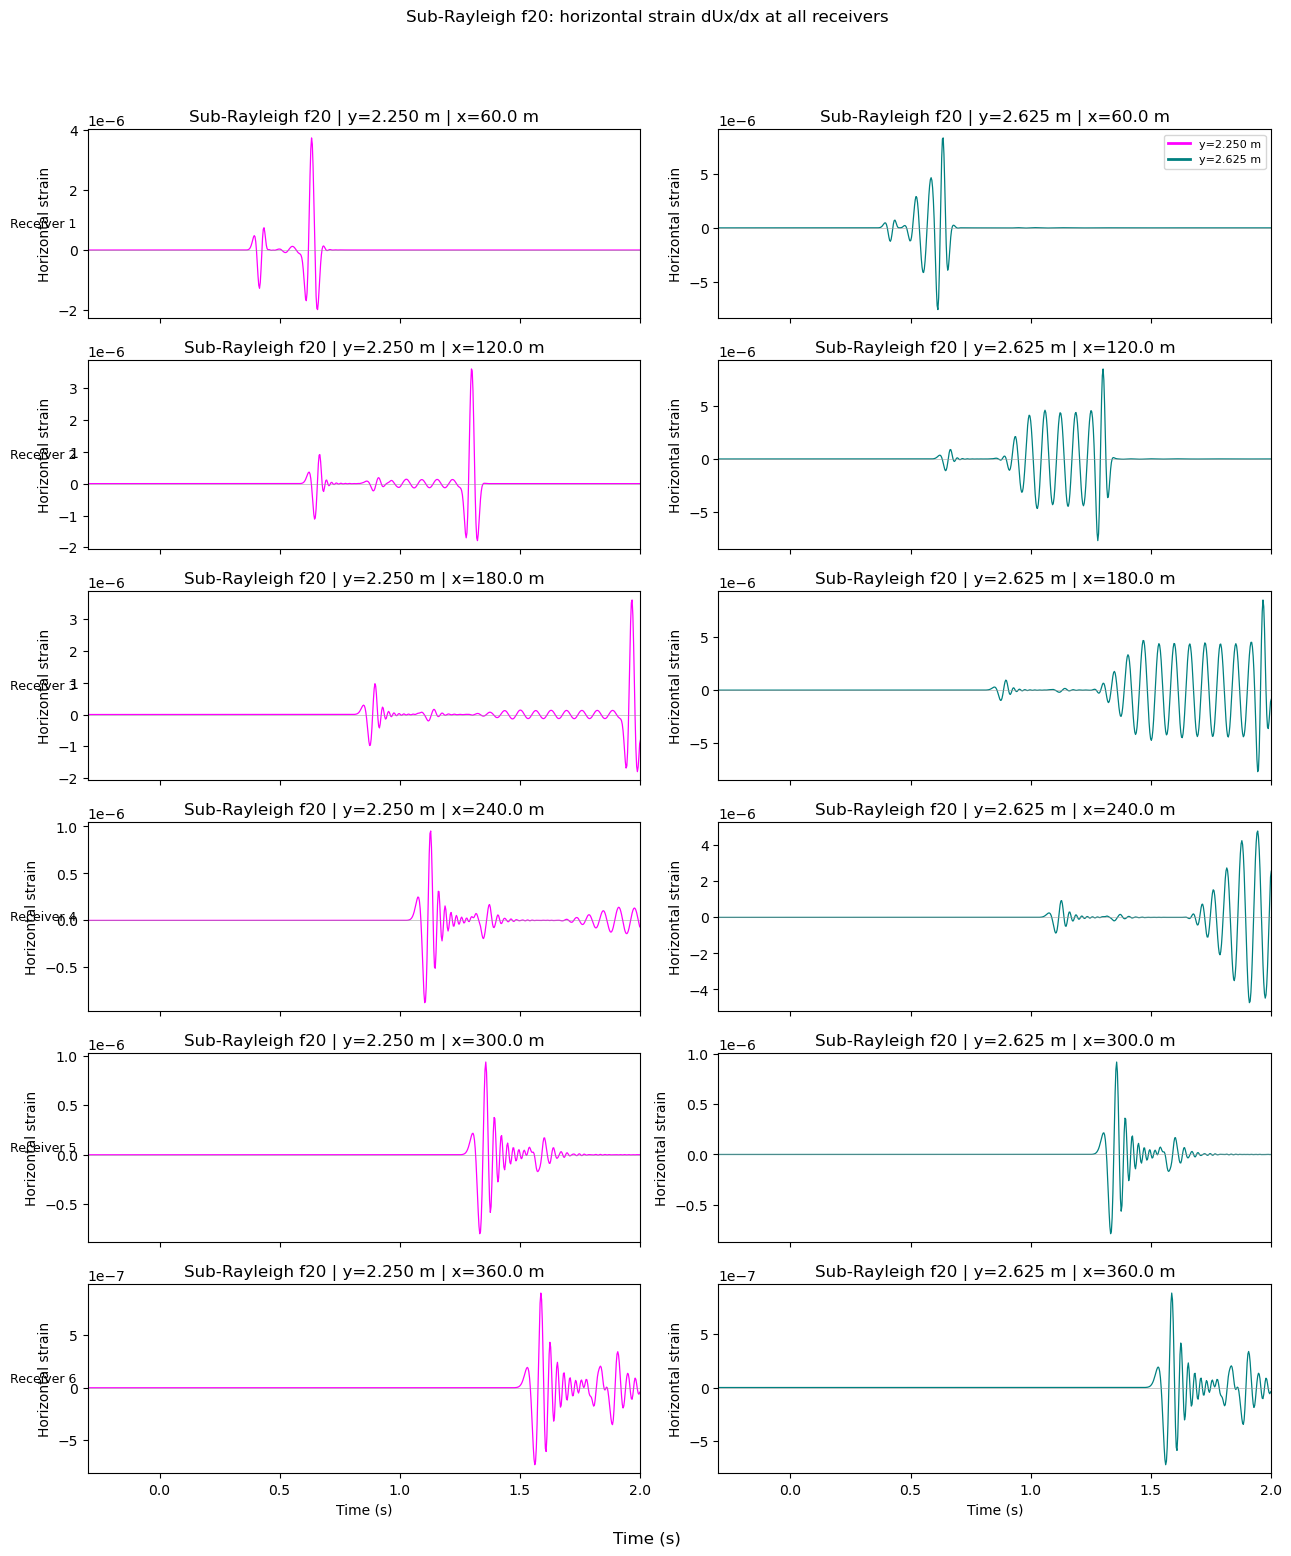

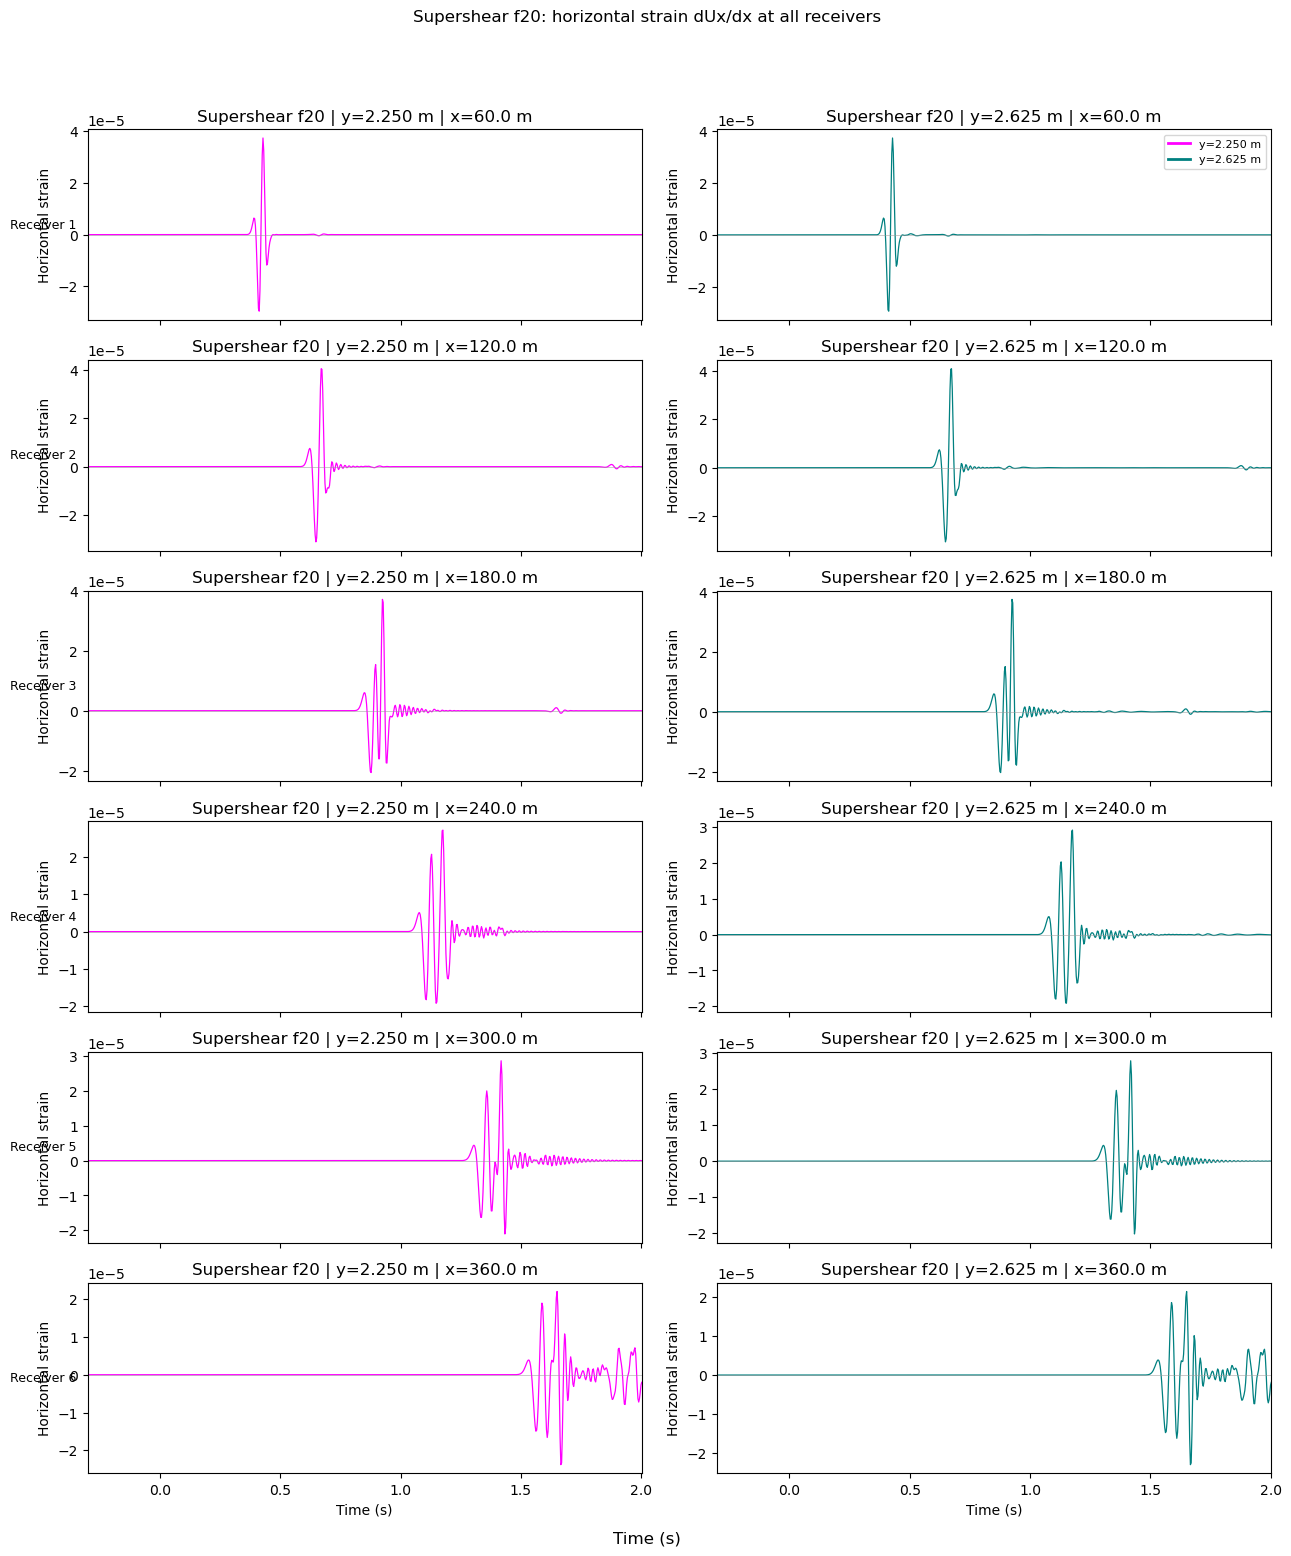

Loaded 20 Hz sub-Rayleigh displacement from simulation_fault_zone_czm_adjusted_time_sub_linear_m1_f20/job_snow_crack_czm/volume_data_czm.h5
Loaded 20 Hz supershear displacement from simulation_fault_zone_czm_adjusted_time_super_linear_m1_f20/job_snow_crack_czm/volume_data_czm.h5
Channel x targets: [60.0, 120.0, 180.0, 240.0, 300.0, 360.0]


In [ ]:
from IPython.display import display
from matplotlib.lines import Line2D
from scipy.signal import butter, lfilter

# Receiver depths
y_surface_1 = globals().get('y_surface_1', 2.25)
y_surface_2 = globals().get('y_surface_2', 2.625)


def _load_czm_displacement_field(project_dir):
    out_file = pathlib.Path(project_dir) / "job_snow_crack_czm" / "volume_data_czm.h5"
    if not out_file.exists():
        raise RuntimeError(f"Missing output file: {out_file}")

    dis_wo = wavefield_output.WavefieldOutput.from_file(out_file, "displacement", "volume")
    dis_2d = wavefield_output.wavefield_output_to_xarray(
        dis_wo,
        points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
    )
    return dis_2d, out_file


def _receiver_strain_section(data_array, receiver_y, component_index=0):
    section, x_name, t_name = _receiver_line_section(data_array, receiver_y, component_index=component_index)
    strain_section = section.differentiate(x_name)
    return strain_section, x_name, t_name


def causal_bandpass_filter(data, low_cutoff_freq, high_cutoff_freq, sampling_rate, order=4):
    """Apply a strict forward-in-time Butterworth bandpass filter."""
    nyquist = 0.5 * sampling_rate
    low = low_cutoff_freq / nyquist
    high = high_cutoff_freq / nyquist
    b, a = butter(order, [low, high], btype="band", analog=False)
    return lfilter(b, a, data)


# Load f20 datasets (reuse globals if present to avoid reloading)
sub_project_dir = pathlib.Path(globals().get("PROJECT_DIR_CZM_SUB_LINEAR_F20", "simulation_fault_zone_czm_adjusted_time_sub_linear_m1_f20"))
super_project_dir = pathlib.Path(globals().get("PROJECT_DIR_CZM_SUPER_LINEAR_F20_SUPER", "simulation_fault_zone_czm_adjusted_time_super_linear_m1_f20"))

dis_sub_20hz, sub_file = _load_czm_displacement_field(sub_project_dir)
dis_super_20hz, super_file = _load_czm_displacement_field(super_project_dir)

# Use x-grid from the sub-Rayleigh case to select receiver x-locations
def _receiver_strain_section_local(data_array, receiver_y, component_index=0):
    coords_set = set(data_array.coords)
    dims_set = set(data_array.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={data_array.dims}, coords={list(data_array.coords)}"
        )

    section = data_array.isel({c_name: component_index}).sel({y_name: receiver_y}, method="nearest")
    strain_section = section.differentiate(x_name).transpose(t_name, x_name)
    return strain_section, x_name, t_name

sub_section_example, sub_x_name, sub_t_name = _receiver_strain_section_local(
    dis_sub_20hz, y_surface_1, component_index=0
)
x_grid = np.asarray(sub_section_example[sub_x_name].values, dtype=float)
channel_targets = np.quantile(x_grid, [0.15, 0.30, 0.45, 0.60, 0.75, 0.90])
channel_names = [f"Receiver {i + 1}" for i in range(len(channel_targets))]


# Colors for the two receiver depths
color_map = {
    "y1": "magenta",
    "y2": "teal",
}


def plot_case_all_receivers(dis_field, case_label):
    # Plot horizontal strain dUx/dx at both receiver depths for all receiver x-locations
    sections = {}
    for depth_tag, receiver_y in [("y1", y_surface_1), ("y2", y_surface_2)]:
        sec, x_name, t_name = _receiver_strain_section(dis_field, receiver_y, component_index=0)
        sections[depth_tag] = (sec, x_name, t_name, receiver_y)

    n_receivers = len(channel_targets)
    fig, axes = plt.subplots(n_receivers, 2, figsize=(13, 2.6 * n_receivers), sharex='col')
    if n_receivers == 1:
        axes = axes.reshape(1, 2)

    for row_idx, (x_target, rname) in enumerate(zip(channel_targets, channel_names)):
        for col_idx, depth_tag in enumerate(["y1", "y2"]):
            section, x_name, t_name, receiver_y = sections[depth_tag]
            x_vals = np.asarray(section[x_name].values, dtype=float)
            idx = int(np.argmin(np.abs(x_vals - float(x_target))))
            trace = section.isel({x_name: idx})
            time_values = np.asarray(trace[t_name].values, dtype=float)
            trace_values = np.asarray(trace.values, dtype=float)

            if len(time_values) > 1:
                dt = float(np.mean(np.diff(time_values)))
                fs = 1.0 / dt
                trace_values = causal_bandpass_filter(
                    trace_values,
                    bandpass_low_hz,
                    bandpass_high_hz,
                    fs,
                    order=4,
                )

            ax = axes[row_idx, col_idx]
            color = color_map[depth_tag]
            ax.plot(time_values, trace_values, lw=0.9, color=color)
            ax.axhline(0.0, color='0.6', lw=0.6, alpha=0.6)
            ax.set_xlim(time_values[0], time_values[-1])
            ax.set_ylabel('Horizontal strain')

            if row_idx == n_receivers - 1:
                ax.set_xlabel('Time (s)')

            ax.set_title(f"{case_label} | y={receiver_y:.3f} m | x={float(x_vals[idx]):.1f} m")

            if col_idx == 0:
                ax.text(-0.02, 0.5, f"{rname}", transform=ax.transAxes, va='center', ha='right', fontsize=9)

    legend_handles = [
        Line2D([0], [0], color=color_map['y1'], lw=2, label=f'y={y_surface_1:.3f} m'),
        Line2D([0], [0], color=color_map['y2'], lw=2, label=f'y={y_surface_2:.3f} m'),
    ]
    axes[0, -1].legend(handles=legend_handles, loc='upper right', fontsize=8)

    fig.supxlabel('Time (s)', fontsize=12)
    fig.suptitle(f"{case_label}: horizontal strain dUx/dx at all receivers", y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    display(fig)
    plt.close(fig)


# Plot for sub-Rayleigh f20
plot_case_all_receivers(dis_sub_20hz, 'Sub-Rayleigh f20')

# Plot for supershear f20
plot_case_all_receivers(dis_super_20hz, 'Supershear f20')

print(f"Loaded 20 Hz sub-Rayleigh displacement from {sub_file}")
print(f"Loaded 20 Hz supershear displacement from {super_file}")
print("Channel x targets:", [float(x) for x in channel_targets])

In [ ]:
from IPython.display import display
from matplotlib.lines import Line2D

# Receiver depths
y_surface_1 = globals().get('y_surface_1', 2.25)
y_surface_2 = globals().get('y_surface_2', 2.625)


def _load_czm_displacement_field(project_dir):
    out_file = pathlib.Path(project_dir) / "job_snow_crack_czm" / "volume_data_czm.h5"
    if not out_file.exists():
        raise RuntimeError(f"Missing output file: {out_file}")

    dis_wo = wavefield_output.WavefieldOutput.from_file(out_file, "displacement", "volume")
    dis_2d = wavefield_output.wavefield_output_to_xarray(
        dis_wo,
        points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
    )
    return dis_2d, out_file


def _receiver_strain_section(data_array, receiver_y, component_index=0):
    section, x_name, t_name = _receiver_line_section(data_array, receiver_y, component_index=component_index)
    strain_section = section.differentiate(x_name)
    return strain_section, x_name, t_name


# Load f20 datasets (reuse globals if present to avoid reloading)
sub_project_dir = pathlib.Path(globals().get("PROJECT_DIR_CZM_SUB_LINEAR_F20", "simulation_fault_zone_czm_adjusted_time_sub_linear_m1_f20"))
super_project_dir = pathlib.Path(globals().get("PROJECT_DIR_CZM_SUPER_LINEAR_F20_SUPER", "simulation_fault_zone_czm_adjusted_time_super_linear_m1_f20"))

dis_sub_20hz, sub_file = _load_czm_displacement_field(sub_project_dir)
dis_super_20hz, super_file = _load_czm_displacement_field(super_project_dir)

# Use x-grid from the sub-Rayleigh case to select receiver x-locations
def _receiver_strain_section_local(data_array, receiver_y, component_index=0):
    coords_set = set(data_array.coords)
    dims_set = set(data_array.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={data_array.dims}, coords={list(data_array.coords)}"
        )

    section = data_array.isel({c_name: component_index}).sel({y_name: receiver_y}, method="nearest")
    strain_section = section.differentiate(x_name).transpose(t_name, x_name)
    return strain_section, x_name, t_name

sub_section_example, sub_x_name, sub_t_name = _receiver_strain_section_local(
    dis_sub_20hz, y_surface_1, component_index=0
)
x_grid = np.asarray(sub_section_example[sub_x_name].values, dtype=float)
channel_targets = np.quantile(x_grid, [0.15, 0.30, 0.45, 0.60, 0.75, 0.90])
channel_names = [f"Receiver {i + 1}" for i in range(len(channel_targets))]


# Colors for the two receiver depths
color_map = {
    "y1": "magenta",
    "y2": "teal",
}


def plot_case_all_receivers(dis_field, case_label):
    # Plot horizontal strain dUx/dx at both receiver depths for all receiver x-locations
    sections = {}
    for depth_tag, receiver_y in [("y1", y_surface_1), ("y2", y_surface_2)]:
        sec, x_name, t_name = _receiver_strain_section(dis_field, receiver_y, component_index=0)
        sections[depth_tag] = (sec, x_name, t_name, receiver_y)

    n_receivers = len(channel_targets)
    fig, axes = plt.subplots(n_receivers, 2, figsize=(13, 2.6 * n_receivers), sharex='col')
    if n_receivers == 1:
        axes = axes.reshape(1, 2)

    for row_idx, (x_target, rname) in enumerate(zip(channel_targets, channel_names)):
        for col_idx, depth_tag in enumerate(["y1", "y2"]):
            section, x_name, t_name, receiver_y = sections[depth_tag]
            x_vals = np.asarray(section[x_name].values, dtype=float)
            idx = int(np.argmin(np.abs(x_vals - float(x_target))))
            trace = section.isel({x_name: idx})
            ax = axes[row_idx, col_idx]
            color = color_map[depth_tag]
            ax.plot(trace[t_name].values, trace.values, lw=0.9, color=color)
            ax.axhline(0.0, color='0.6', lw=0.6, alpha=0.6)
            ax.set_xlim(trace[t_name].values[0], trace[t_name].values[-1])
            ax.set_ylabel('Horizontal strain')

            if row_idx == n_receivers - 1:
                ax.set_xlabel('Time (s)')

            ax.set_title(f"{case_label} | y={receiver_y:.3f} m | x={float(x_vals[idx]):.1f} m")

            if col_idx == 0:
                ax.text(-0.02, 0.5, f"{rname}", transform=ax.transAxes, va='center', ha='right', fontsize=9)

    legend_handles = [
        Line2D([0], [0], color=color_map['y1'], lw=2, label=f'y={y_surface_1:.3f} m'),
        Line2D([0], [0], color=color_map['y2'], lw=2, label=f'y={y_surface_2:.3f} m'),
    ]
    axes[0, -1].legend(handles=legend_handles, loc='upper right', fontsize=8)

    fig.supxlabel('Time (s)', fontsize=12)
    fig.suptitle(f"{case_label}: horizontal strain dUx/dx at all receivers", y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    display(fig)
    plt.close(fig)


# Plot for sub-Rayleigh f20
plot_case_all_receivers(dis_sub_20hz, 'Sub-Rayleigh f20')

# Plot for supershear f20
plot_case_all_receivers(dis_super_20hz, 'Supershear f20')

print(f"Loaded 20 Hz sub-Rayleigh displacement from {sub_file}")
print(f"Loaded 20 Hz supershear displacement from {super_file}")
print("Channel x targets:", [float(x) for x in channel_targets])

In [ ]:
from IPython.display import display
from matplotlib.lines import Line2D

# Receiver depths
y_surface_1 = globals().get('y_surface_1', 2.25)
y_surface_2 = globals().get('y_surface_2', 2.625)


def _load_czm_displacement_field(project_dir):
    out_file = pathlib.Path(project_dir) / "job_snow_crack_czm" / "volume_data_czm.h5"
    if not out_file.exists():
        raise RuntimeError(f"Missing output file: {out_file}")

    dis_wo = wavefield_output.WavefieldOutput.from_file(out_file, "displacement", "volume")
    dis_2d = wavefield_output.wavefield_output_to_xarray(
        dis_wo,
        points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
    )
    return dis_2d, out_file


# Load f20 datasets (reuse globals if present to avoid reloading)
sub_project_dir = pathlib.Path(globals().get("PROJECT_DIR_CZM_SUB_LINEAR_F20", "simulation_fault_zone_czm_adjusted_time_sub_linear_m1_f20"))
super_project_dir = pathlib.Path(globals().get("PROJECT_DIR_CZM_SUPER_LINEAR_F20_SUPER", "simulation_fault_zone_czm_adjusted_time_super_linear_m1_f20"))

dis_sub_20hz, sub_file = _load_czm_displacement_field(sub_project_dir)
dis_super_20hz, super_file = _load_czm_displacement_field(super_project_dir)

# Use x-grid from the sub-Rayleigh case to select receiver x-locations
def _receiver_displacement_section(data_array, receiver_y, component_index=0):
    coords_set = set(data_array.coords)
    dims_set = set(data_array.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={data_array.dims}, coords={list(data_array.coords)}"
        )

    section = data_array.isel({c_name: component_index}).sel({y_name: receiver_y}, method="nearest")
    displacement_section = section.transpose(t_name, x_name)
    return displacement_section, x_name, t_name


sub_section_example, sub_x_name, sub_t_name = _receiver_displacement_section(
    dis_sub_20hz, y_surface_1, component_index=0
)
x_grid = np.asarray(sub_section_example[sub_x_name].values, dtype=float)
channel_targets = np.quantile(x_grid, [0.15, 0.30, 0.45, 0.60, 0.75, 0.90])
channel_names = [f"Receiver {i + 1}" for i in range(len(channel_targets))]


# Colors for the two receiver depths
color_map = {
    "y1": "magenta",
    "y2": "teal",
}


def plot_case_all_receivers(dis_field, case_label):
    # Plot horizontal displacement Ux at both receiver depths for all receiver x-locations
    sections = {}
    for depth_tag, receiver_y in [("y1", y_surface_1), ("y2", y_surface_2)]:
        sec, x_name, t_name = _receiver_displacement_section(dis_field, receiver_y, component_index=0)
        sections[depth_tag] = (sec, x_name, t_name, receiver_y)

    n_receivers = len(channel_targets)
    fig, axes = plt.subplots(n_receivers, 2, figsize=(13, 2.6 * n_receivers), sharex='col')
    if n_receivers == 1:
        axes = axes.reshape(1, 2)

    for row_idx, (x_target, rname) in enumerate(zip(channel_targets, channel_names)):
        for col_idx, depth_tag in enumerate(["y1", "y2"]):
            section, x_name, t_name, receiver_y = sections[depth_tag]
            x_vals = np.asarray(section[x_name].values, dtype=float)
            idx = int(np.argmin(np.abs(x_vals - float(x_target))))
            trace = section.isel({x_name: idx})
            ax = axes[row_idx, col_idx]
            color = color_map[depth_tag]
            ax.plot(trace[t_name].values, trace.values, lw=0.9, color=color)
            ax.axhline(0.0, color='0.6', lw=0.6, alpha=0.6)
            ax.set_xlim(trace[t_name].values[0], trace[t_name].values[-1])
            ax.set_ylabel('Horizontal displacement')

            if row_idx == n_receivers - 1:
                ax.set_xlabel('Time (s)')

            ax.set_title(f"{case_label} | y={receiver_y:.3f} m | x={float(x_vals[idx]):.1f} m")

            if col_idx == 0:
                ax.text(-0.02, 0.5, f"{rname}", transform=ax.transAxes, va='center', ha='right', fontsize=9)

    legend_handles = [
        Line2D([0], [0], color=color_map['y1'], lw=2, label=f'y={y_surface_1:.3f} m'),
        Line2D([0], [0], color=color_map['y2'], lw=2, label=f'y={y_surface_2:.3f} m'),
    ]
    axes[0, -1].legend(handles=legend_handles, loc='upper right', fontsize=8)

    fig.supxlabel('Time (s)', fontsize=12)
    fig.suptitle(f"{case_label}: horizontal displacement Ux at all receivers", y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    display(fig)
    plt.close(fig)


# Plot for sub-Rayleigh f20
plot_case_all_receivers(dis_sub_20hz, 'Sub-Rayleigh f20')

# Plot for supershear f20
plot_case_all_receivers(dis_super_20hz, 'Supershear f20')

print(f"Loaded 20 Hz sub-Rayleigh displacement from {sub_file}")
print(f"Loaded 20 Hz supershear displacement from {super_file}")
print("Channel x targets:", [float(x) for x in channel_targets])

In [ ]:
from IPython.display import display
from matplotlib.lines import Line2D
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from salvus.toolbox.helpers import wavefield_output

# Receiver depths
y_surface_1 = globals().get('y_surface_1', 2.25)
y_surface_2 = globals().get('y_surface_2', 2.625)


def _load_czm_displacement_field(project_dir):
    out_file = pathlib.Path(project_dir) / "job_snow_crack_czm" / "volume_data_czm.h5"
    if not out_file.exists():
        raise RuntimeError(f"Missing output file: {out_file}")

    dis_wo = wavefield_output.WavefieldOutput.from_file(out_file, "displacement", "volume")
    dis_2d = wavefield_output.wavefield_output_to_xarray(
        dis_wo,
        points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
    )
    return dis_2d, out_file


def _receiver_strain_rate_section(data_array, receiver_y, component_index=0):
    coords_set = set(data_array.coords)
    dims_set = set(data_array.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={data_array.dims}, coords={list(data_array.coords)}"
        )

    section = data_array.isel({c_name: component_index}).sel({y_name: receiver_y}, method="nearest")
    # horizontal strain = dUx/dx
    strain_section = section.differentiate(x_name).transpose(t_name, x_name)
    # strain rate = temporal derivative of strain
    strain_rate_section = strain_section.differentiate(t_name)
    return strain_rate_section, x_name, t_name


# Load f20 datasets (reuse globals if present to avoid reloading)
sub_project_dir = pathlib.Path(globals().get("PROJECT_DIR_CZM_SUB_LINEAR_F20", "simulation_fault_zone_czm_adjusted_time_sub_linear_m1_f20"))
super_project_dir = pathlib.Path(globals().get("PROJECT_DIR_CZM_SUPER_LINEAR_F20_SUPER", "simulation_fault_zone_czm_adjusted_time_super_linear_m1_f20"))

dis_sub_20hz, sub_file = _load_czm_displacement_field(sub_project_dir)
dis_super_20hz, super_file = _load_czm_displacement_field(super_project_dir)

# Use x-grid from the sub-Rayleigh case to select receiver x-locations
sub_section_example, sub_x_name, sub_t_name = _receiver_strain_rate_section(
    dis_sub_20hz, y_surface_1, component_index=0
)
x_grid = np.asarray(sub_section_example[sub_x_name].values, dtype=float)
channel_targets = np.quantile(x_grid, [0.15, 0.30, 0.45, 0.60, 0.75, 0.90])
channel_names = [f"Receiver {i + 1}" for i in range(len(channel_targets))]


# Colors for the two receiver depths
color_map = {
    "y1": "magenta",
    "y2": "teal",
}


def plot_case_all_receivers_strain_rate(dis_field, case_label):
    # Plot strain rate (d/dt of dUx/dx) at both receiver depths for all receiver x-locations
    sections = {}
    for depth_tag, receiver_y in [("y1", y_surface_1), ("y2", y_surface_2)]:
        sec, x_name, t_name = _receiver_strain_rate_section(dis_field, receiver_y, component_index=0)
        sections[depth_tag] = (sec, x_name, t_name, receiver_y)

    n_receivers = len(channel_targets)
    fig, axes = plt.subplots(n_receivers, 2, figsize=(13, 2.6 * n_receivers), sharex='col')
    if n_receivers == 1:
        axes = axes.reshape(1, 2)

    for row_idx, (x_target, rname) in enumerate(zip(channel_targets, channel_names)):
        for col_idx, depth_tag in enumerate(["y1", "y2"]):
            section, x_name, t_name, receiver_y = sections[depth_tag]
            x_vals = np.asarray(section[x_name].values, dtype=float)
            idx = int(np.argmin(np.abs(x_vals - float(x_target))))
            trace = section.isel({x_name: idx})
            ax = axes[row_idx, col_idx]
            color = color_map[depth_tag]
            ax.plot(trace[t_name].values, trace.values, lw=0.9, color=color)
            ax.axhline(0.0, color='0.6', lw=0.6, alpha=0.6)
            ax.set_xlim(trace[t_name].values[0], trace[t_name].values[-1])
            ax.set_ylabel('Strain rate (1/s)')

            if row_idx == n_receivers - 1:
                ax.set_xlabel('Time (s)')

            ax.set_title(f"{case_label} | y={receiver_y:.3f} m | x={float(x_vals[idx]):.1f} m")

            if col_idx == 0:
                ax.text(-0.02, 0.5, f"{rname}", transform=ax.transAxes, va='center', ha='right', fontsize=9)

    legend_handles = [
        Line2D([0], [0], color=color_map['y1'], lw=2, label=f'y={y_surface_1:.3f} m'),
        Line2D([0], [0], color=color_map['y2'], lw=2, label=f'y={y_surface_2:.3f} m'),
    ]
    axes[0, -1].legend(handles=legend_handles, loc='upper right', fontsize=8)

    fig.supxlabel('Time (s)', fontsize=12)
    fig.suptitle(f"{case_label}: strain rate (d/dt dUx/dx) at all receivers", y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    display(fig)
    plt.close(fig)


# Plot for sub-Rayleigh f20
plot_case_all_receivers_strain_rate(dis_sub_20hz, 'Sub-Rayleigh f20')

# Plot for supershear f20
plot_case_all_receivers_strain_rate(dis_super_20hz, 'Supershear f20')

print(f"Loaded 20 Hz sub-Rayleigh displacement from {sub_file}")
print(f"Loaded 20 Hz supershear displacement from {super_file}")
print("Channel x targets:", [float(x) for x in channel_targets])